# Label-Channel Bias All Model All Domain Comparison
This notebook generates plots for comparing models to determine if each one displays label channel bias on high positive case across all domains and models.
Load data by running `data_processing.ipynb` first.

## Setup

In [1]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
os.chdir("../..")

## Lookup Maps and Style Constants

In [3]:
rewards_per_scale = {
    'high_scale':     [75, 50, 25],
    'low_scale':      [0.75, 0.5, 0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale':  [-0.25, -0.5, -0.75],
}

STYLE_CONSTANTS = {
    'max_val': {
        'linestyle': '--',
        'color': 'black',
        'label': 'Maximum',
    },
    'min_val': {
        'linestyle': '--',
        'color': 'firebrick',
        'label': 'Minimum',
    },
}

# Styles for cum_regret (and helpful noms in exploration_count)
NOM_STYLE_CONSTANTS = {
    'alphanumeric':     {'color': 'black',      'linestyle': '-', 'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful':  {'color': 'steelblue',  'linestyle': '-', 'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead':  {'color': 'steelblue',  'linestyle': '-', 'marker': 'o', 'label': 'Ordinal - Misleading'},
    'world_helpful':    {'color': 'darkgreen',  'linestyle': '-', 'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':    {'color': 'darkgreen',  'linestyle': '-', 'marker': 'o', 'label': 'World - Misleading'},
    'sent_new_helpful': {'color': 'darkorchid', 'linestyle': '-', 'marker': 'o', 'label': 'Sentiment - Helpful'},
    'sent_new_mislead': {'color': 'darkorchid', 'linestyle': '-', 'marker': 'o', 'label': 'Sentiment - Misleading'},
}

# Styles for mislead noms in exploration_count: lighter colour, dotted, triangle marker
NOM_STYLE_MISLEAD_EXPLOR = {
    'ordinal_mislead':  {'color': 'cornflowerblue', 'linestyle': ':', 'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_mislead':    {'color': 'mediumseagreen',  'linestyle': ':', 'marker': '^', 'label': 'World - Misleading'},
    'sent_new_mislead': {'color': 'orchid',          'linestyle': ':', 'marker': '^', 'label': 'Sentiment - Misleading'},
}

# Small vertical offsets to separate overlapping lines (applied to y-values)
NOM_Y_JITTER = {
    'alphanumeric':      0.000,
    'ordinal_helpful':  -0.015,
    'ordinal_mislead':  -0.010,
    'world_helpful':    -0.005,
    'world_mislead':     0.005,
    'sent_new_helpful':  0.010,
    'sent_new_mislead':  0.015,
}

nom_legend_order = [
    'alphanumeric',
    'ordinal_helpful', 'ordinal_mislead',
    'world_helpful',   'world_mislead',
    'sent_new_helpful', 'sent_new_mislead',
]

nomenclature_map = {
    'alphanumeric':     'Alphanumeric',
    'ordinal_helpful':  'Ordinal - Helpful',
    'ordinal_mislead':  'Ordinal - Misleading',
    'world_helpful':    'World - Helpful',
    'world_mislead':    'World - Misleading',
    'sent_new_helpful': 'Sentiment - Helpful',
    'sent_new_mislead': 'Sentiment - Misleading',
}

metric_map = {
    'cum_regret':        'Scaled Cum. Regret',
    'exploration_count': 'States Explored',
}

## Configuration

In [4]:
# Load merged results from data_processing.ipynb output
results_df = pd.read_csv('experiments/merged_sem_var_results.csv')
print(f"Loaded {len(results_df)} rows")
results_df[['domain', 'model', 'history', 'variance']].value_counts().reset_index(name='count')

Loaded 1505 rows


,domain,model,history,variance,count
0,Farm,Qwen3-32B,Summarized,No,36
1,Farm,Qwen3-32B,Summarized,Low,36
2,Farm,Qwen3-32B,Summarized,High,36
3,Farm,Qwen3-14B,Summarized,No,36
4,Farm,Qwen3-14B,Summarized,Low,36
5,Farm,Qwen3-14B,Summarized,High,36
6,Farm,Llama3-8B,Summarized,High,36
7,Farm,Llama3-8B,Summarized,Low,36
8,Clothing Recommendation,Llama3-8B,Summarized,No,29
9,Bandit,Llama3-8B,Summarized,High,28


In [5]:
# Scale to focus on
SCALE = 'high_scale'

# Nomenclature groups — alphanumeric included in both
nom_groups = {
    'helpful': ['alphanumeric', 'ordinal_helpful', 'world_helpful', 'sent_new_helpful'],
    'mislead': ['alphanumeric', 'ordinal_mislead', 'world_mislead', 'sent_new_mislead'],
}

# Preferred domain column order (any not in this list are appended at the end)
domain_order = ['Bandit', 'Farm', 'Clothing Recommendation']

# Variance conditions to generate separate figures for
all_variances = ['No', 'Low', 'High']

# History filter
hist = 'Summarized'

## Plotting

One figure per model × metric × variance. Each figure has one subplot per domain (columns).
Each subplot shows one line per nomenclature, all for the `high_scale` (positive high) condition.

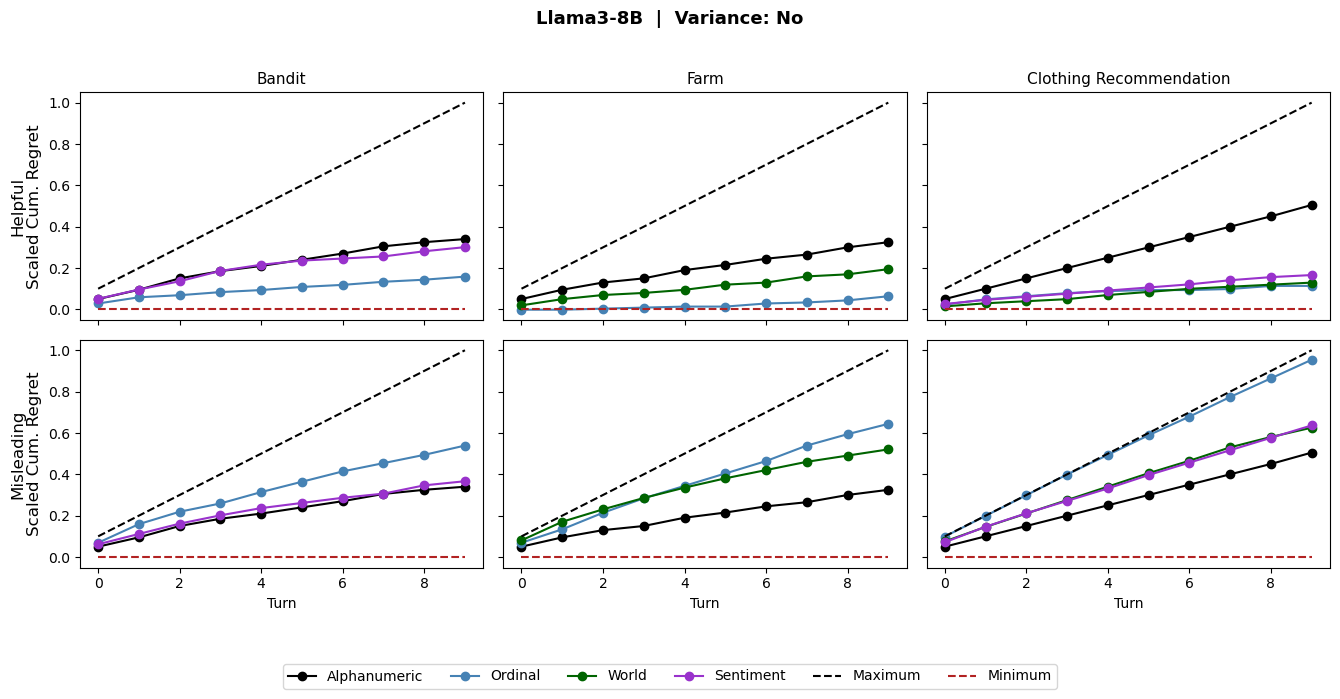

Saved cum_regret: model=Llama3-8B, variance=No


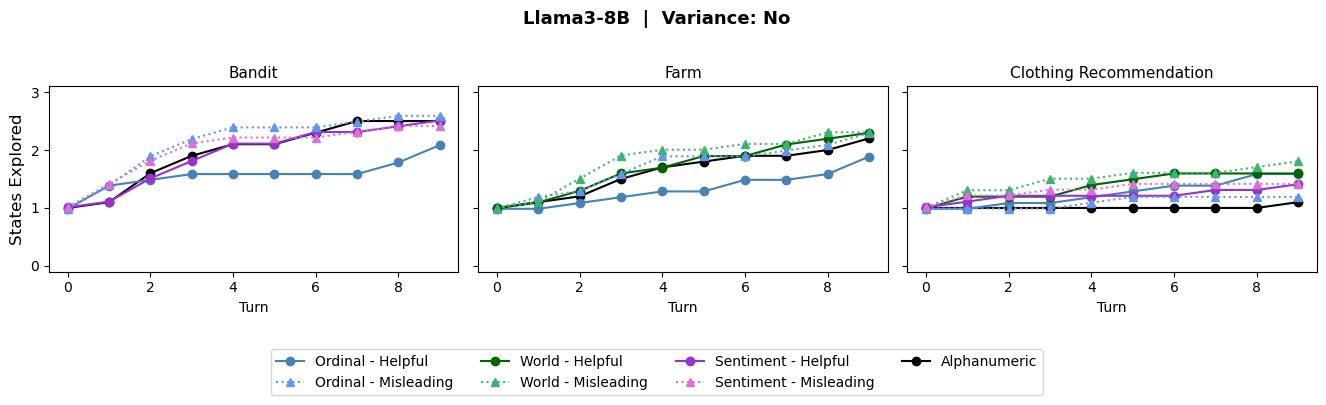

Saved exploration_count: model=Llama3-8B, variance=No


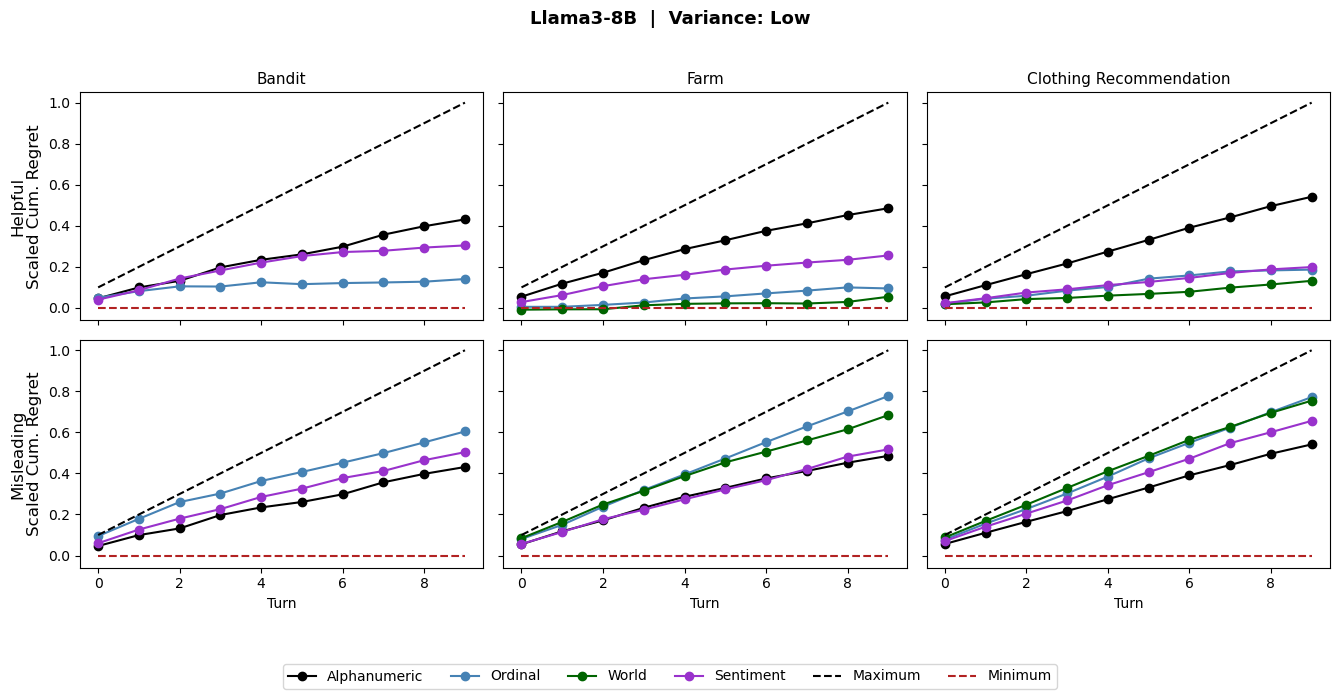

Saved cum_regret: model=Llama3-8B, variance=Low


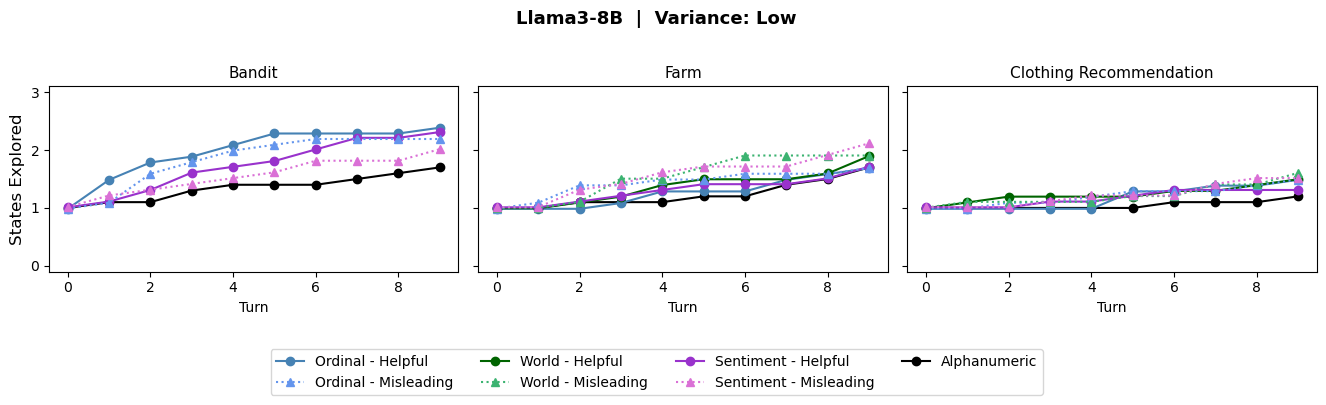

Saved exploration_count: model=Llama3-8B, variance=Low


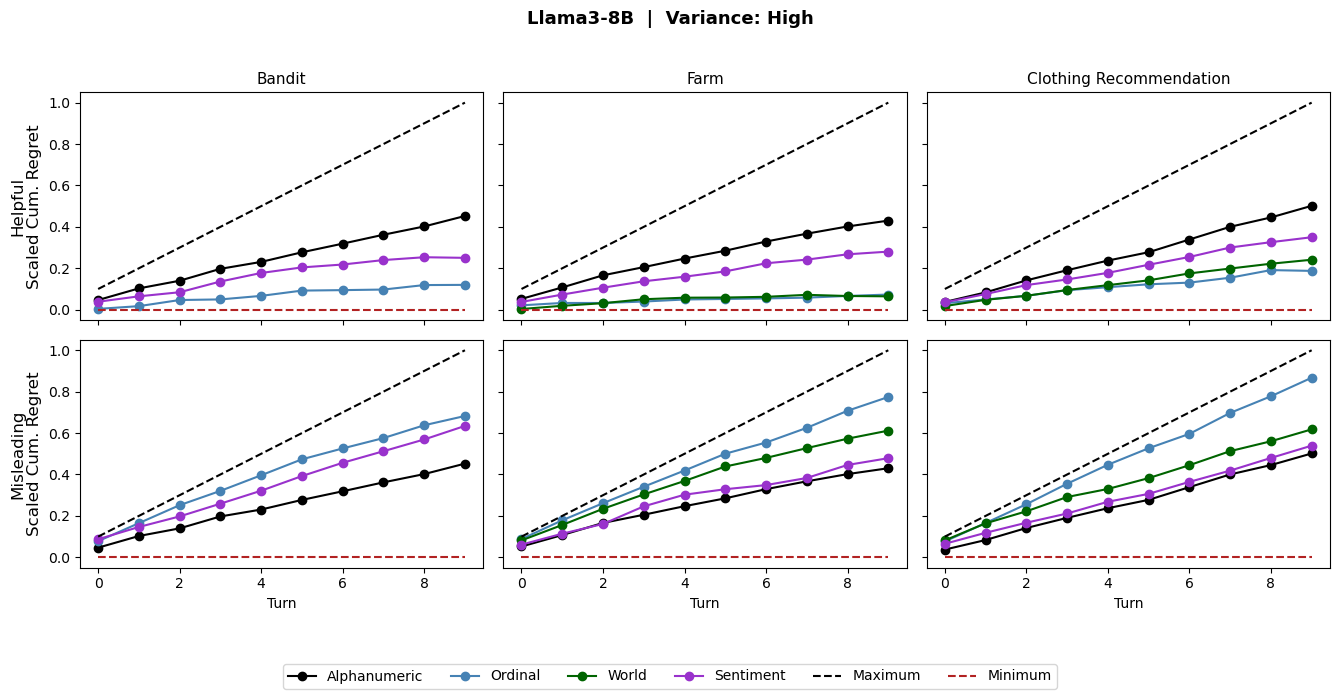

Saved cum_regret: model=Llama3-8B, variance=High


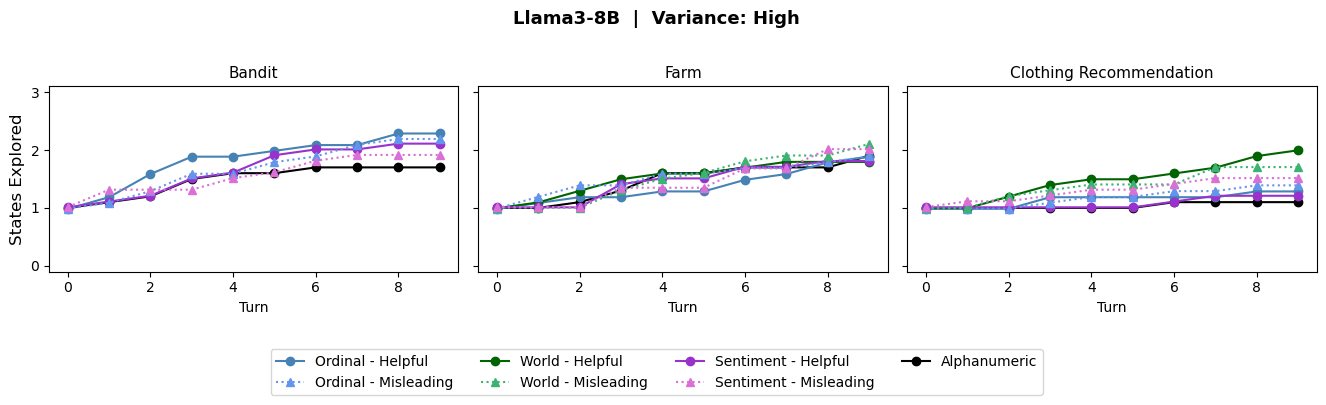

Saved exploration_count: model=Llama3-8B, variance=High


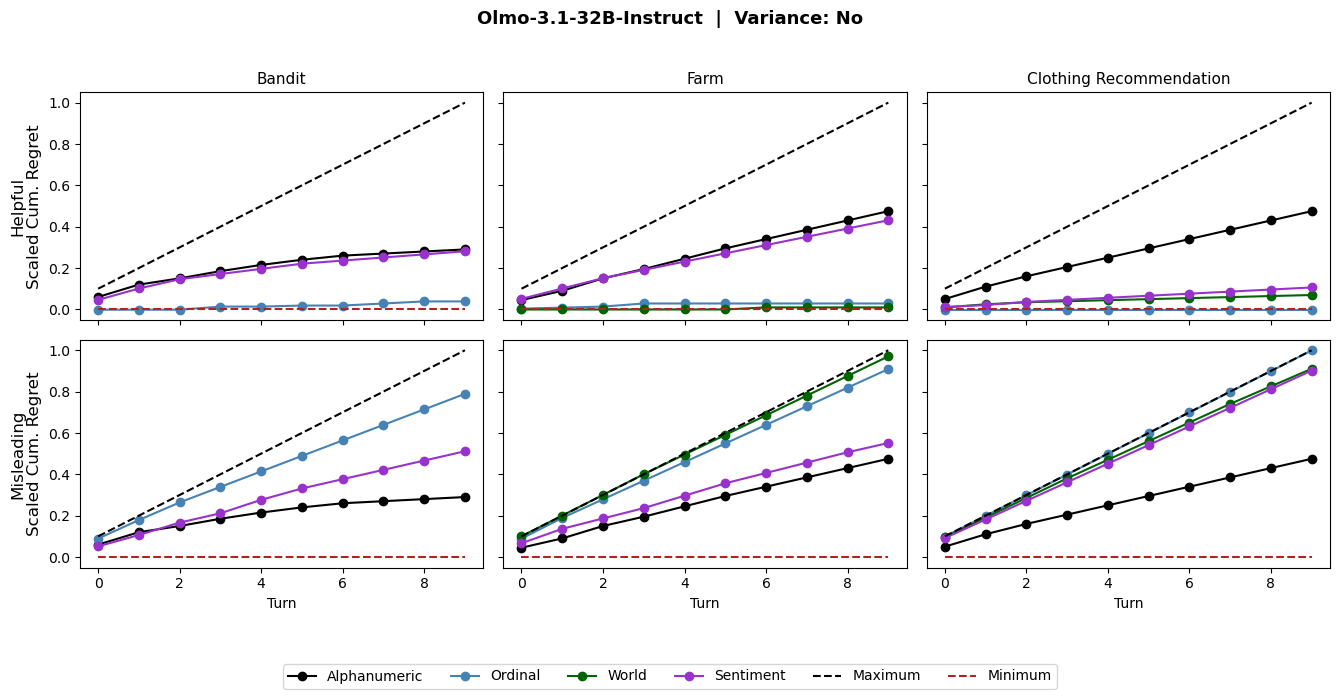

Saved cum_regret: model=Olmo-3.1-32B-Instruct, variance=No


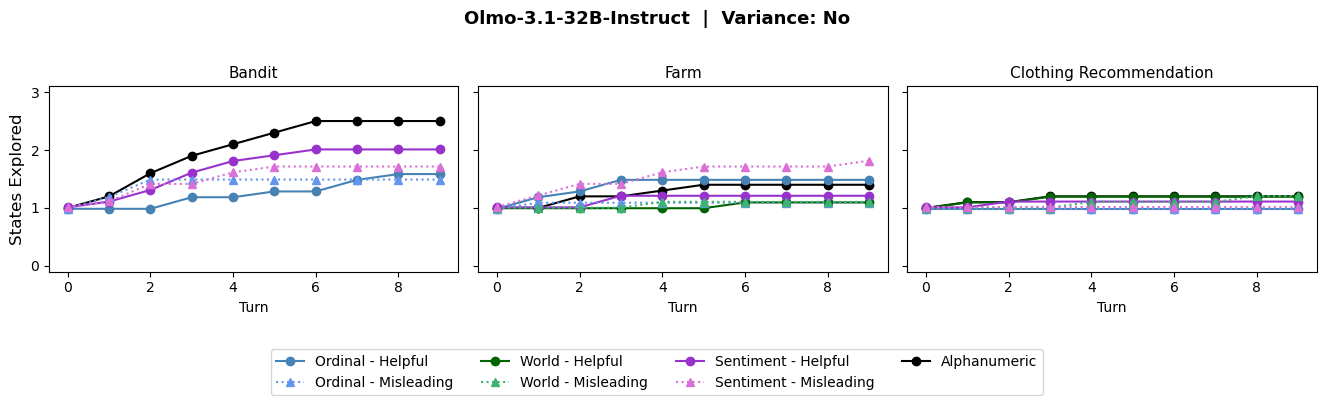

Saved exploration_count: model=Olmo-3.1-32B-Instruct, variance=No


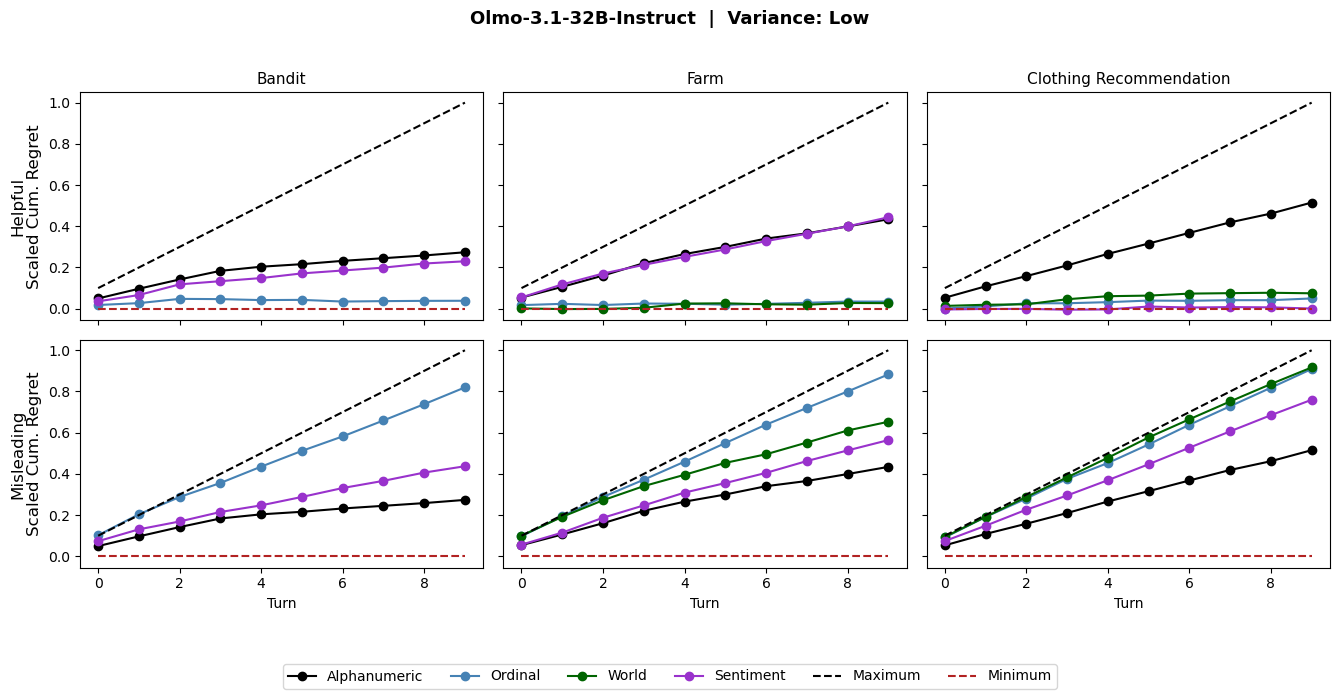

Saved cum_regret: model=Olmo-3.1-32B-Instruct, variance=Low


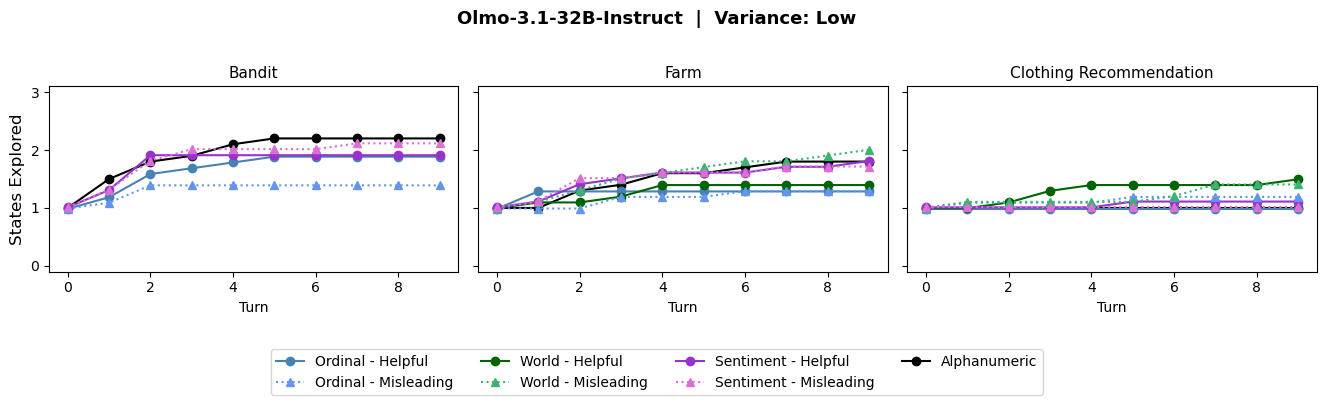

Saved exploration_count: model=Olmo-3.1-32B-Instruct, variance=Low


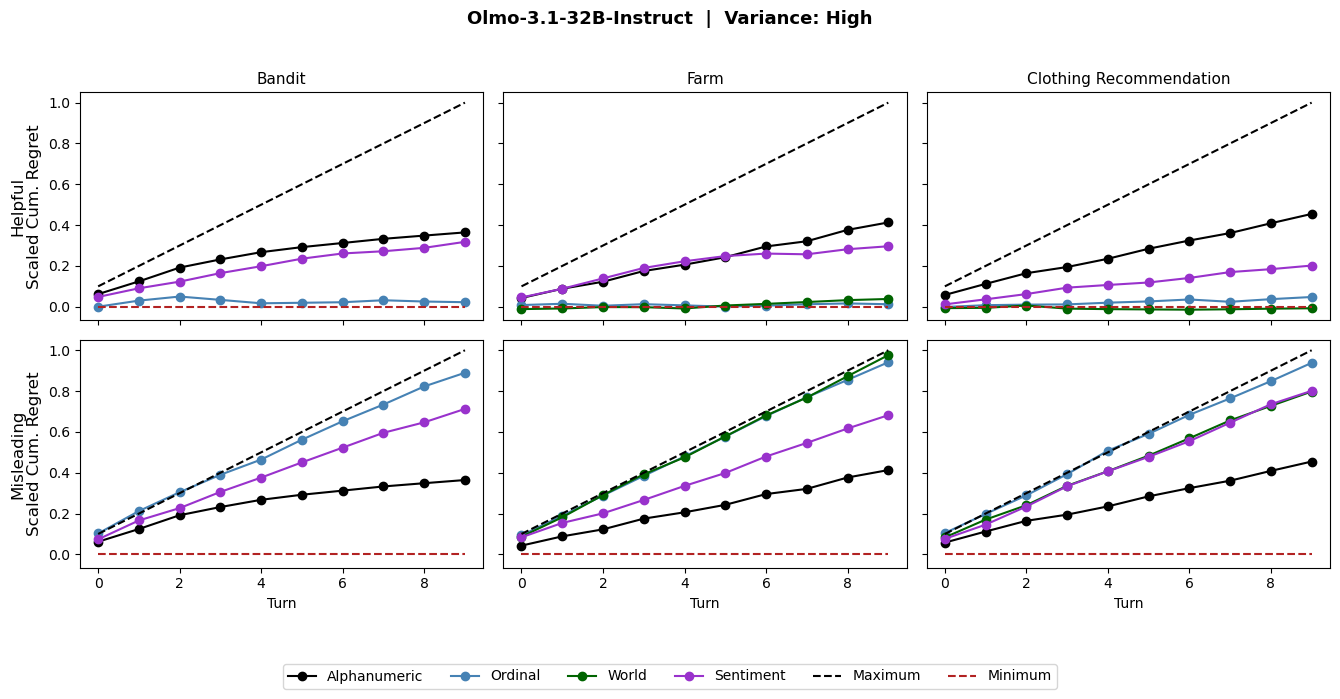

Saved cum_regret: model=Olmo-3.1-32B-Instruct, variance=High


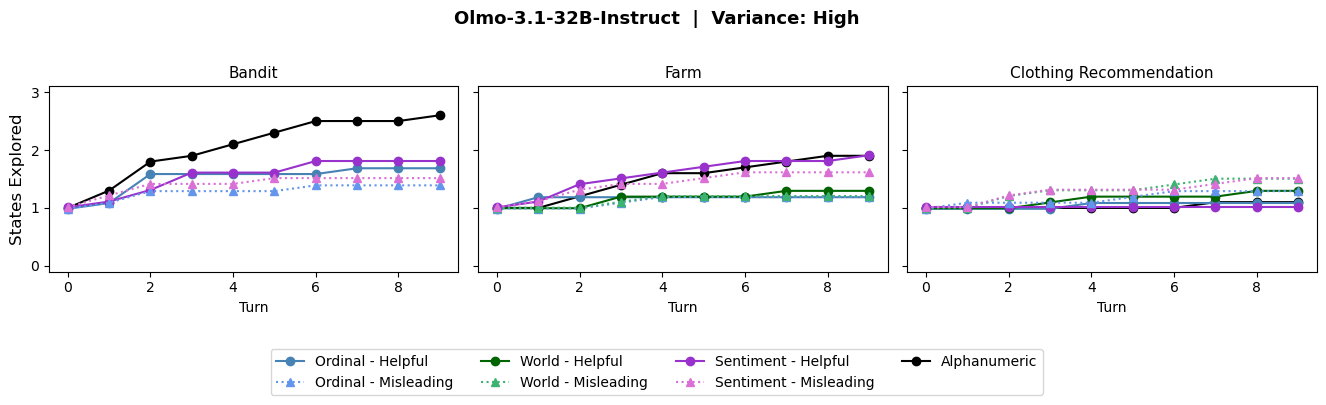

Saved exploration_count: model=Olmo-3.1-32B-Instruct, variance=High


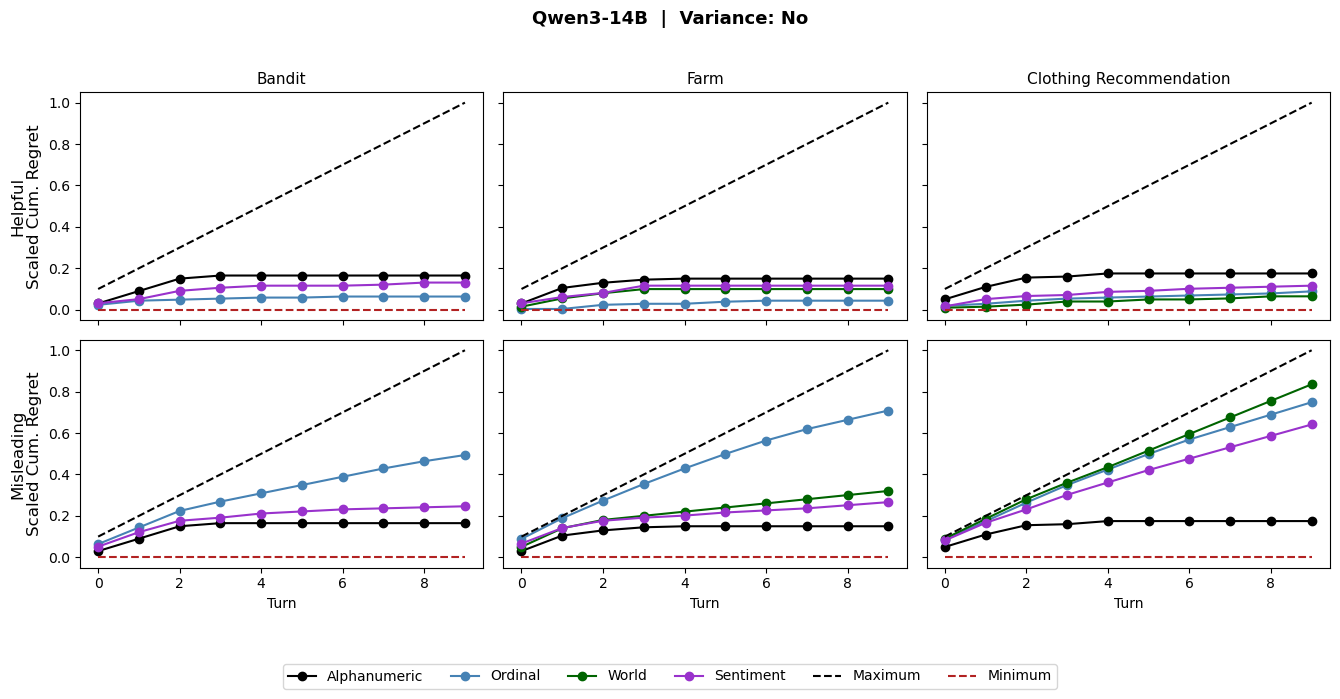

Saved cum_regret: model=Qwen3-14B, variance=No


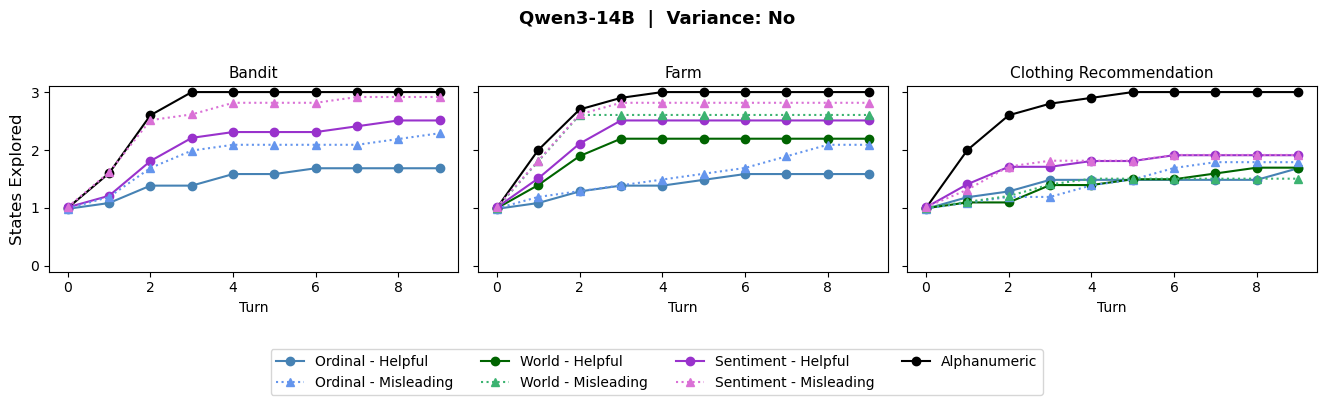

Saved exploration_count: model=Qwen3-14B, variance=No


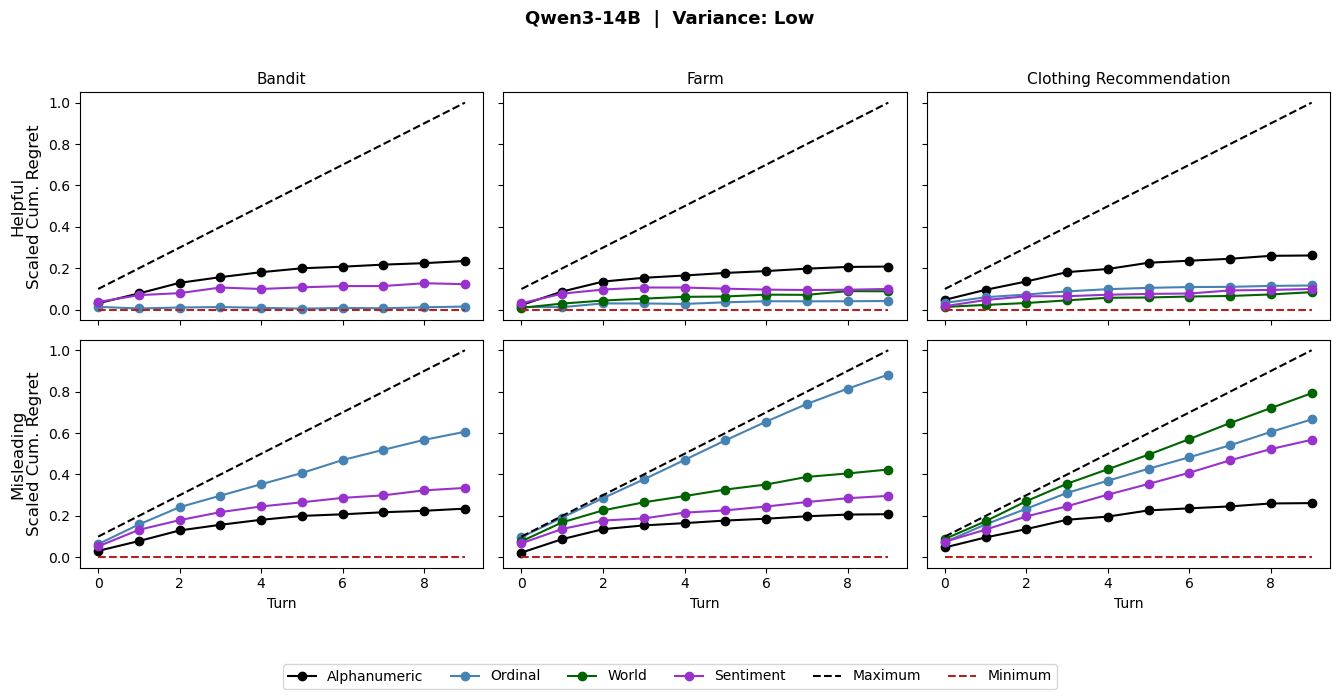

Saved cum_regret: model=Qwen3-14B, variance=Low


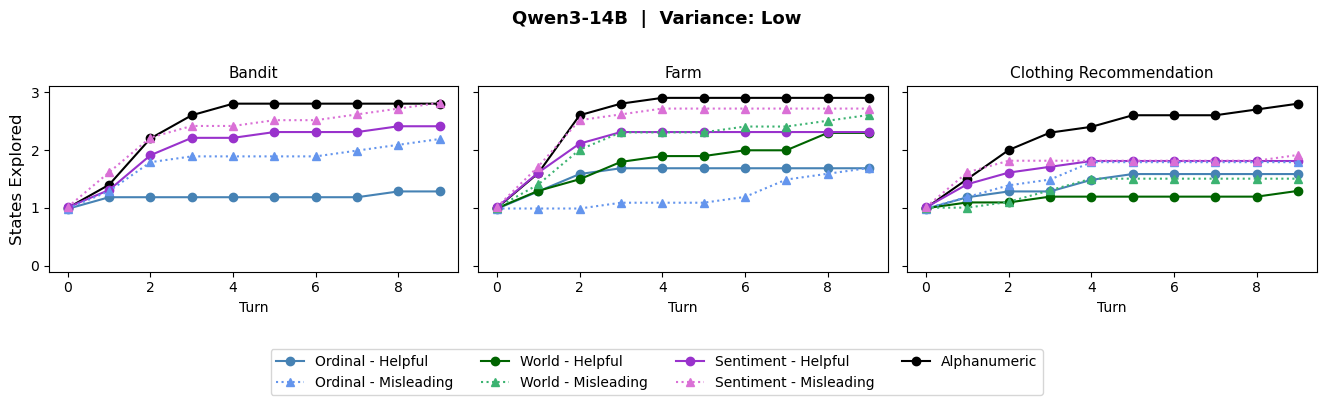

Saved exploration_count: model=Qwen3-14B, variance=Low


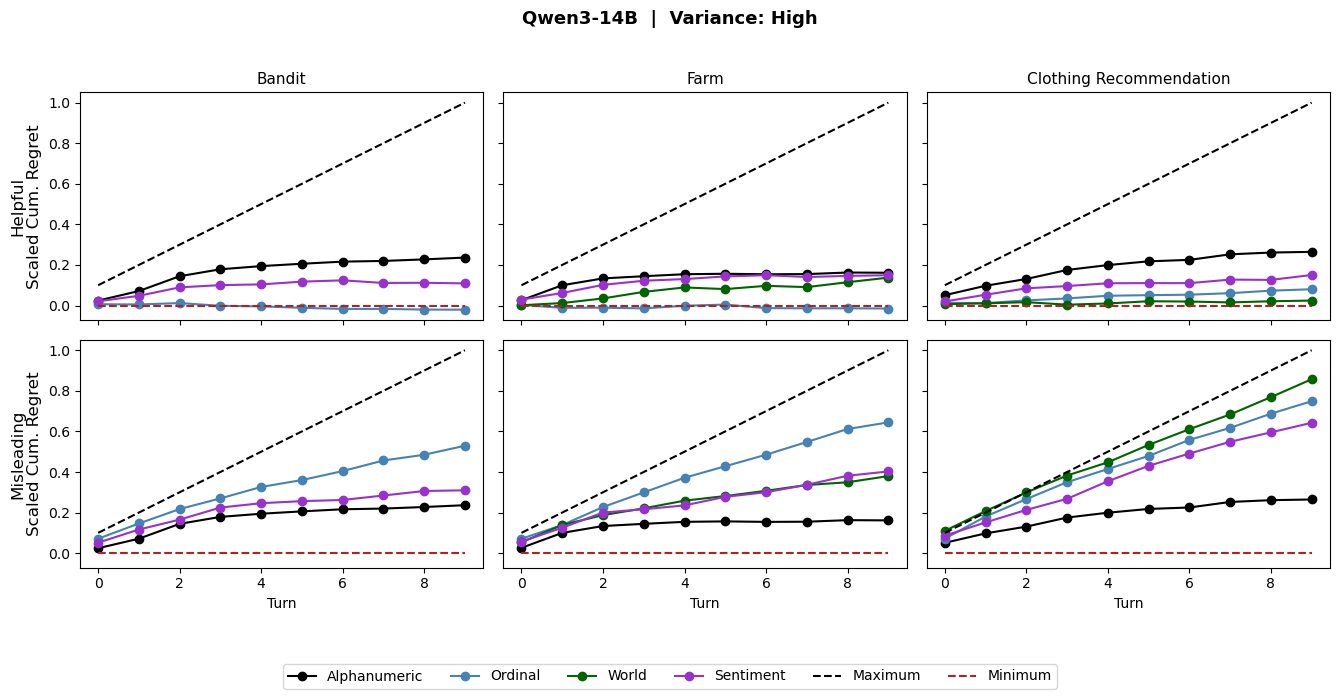

Saved cum_regret: model=Qwen3-14B, variance=High


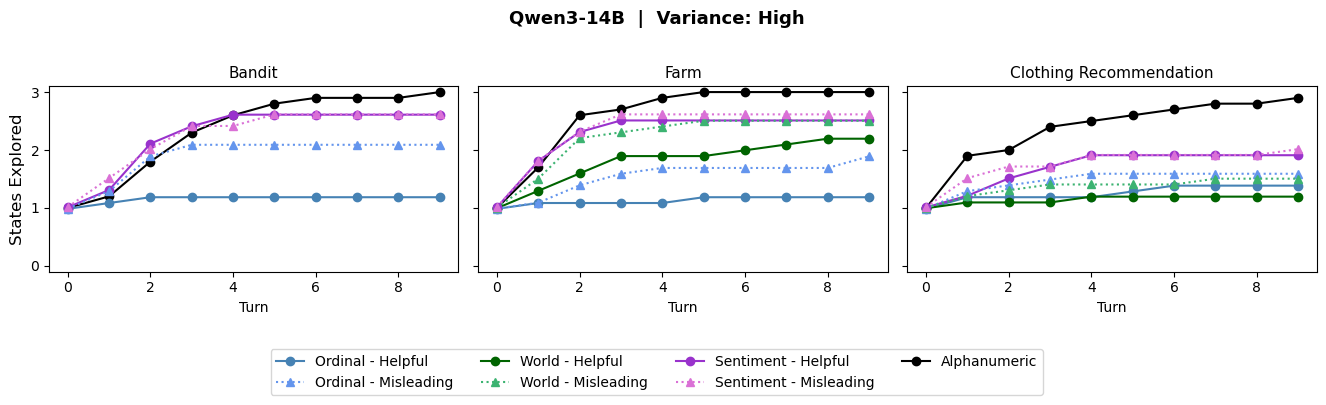

Saved exploration_count: model=Qwen3-14B, variance=High


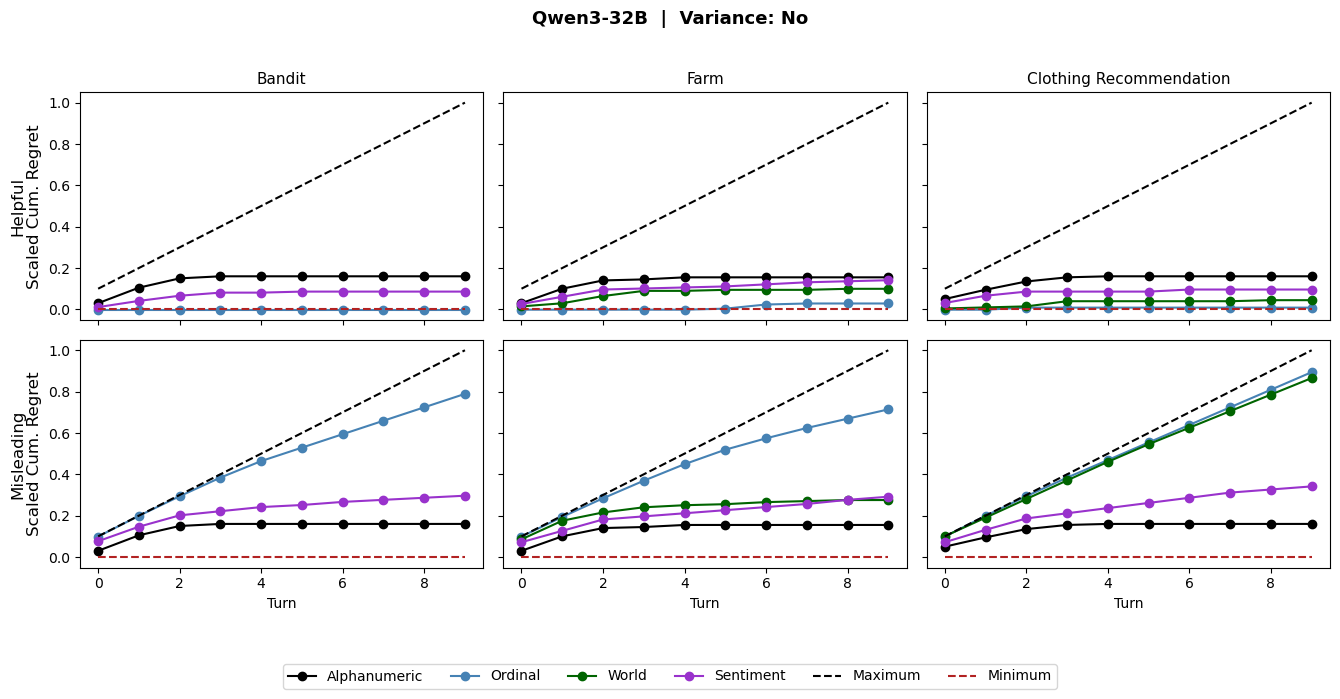

Saved cum_regret: model=Qwen3-32B, variance=No


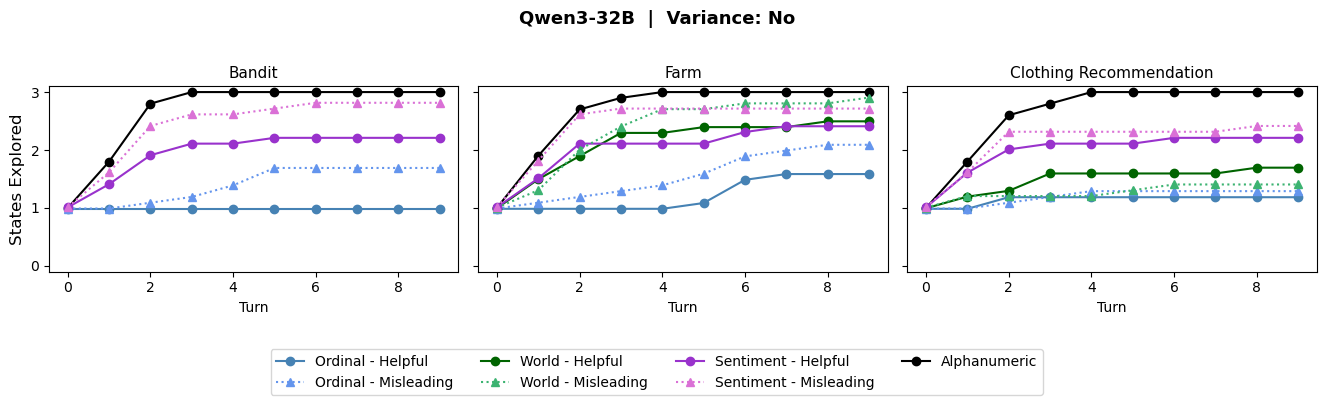

Saved exploration_count: model=Qwen3-32B, variance=No


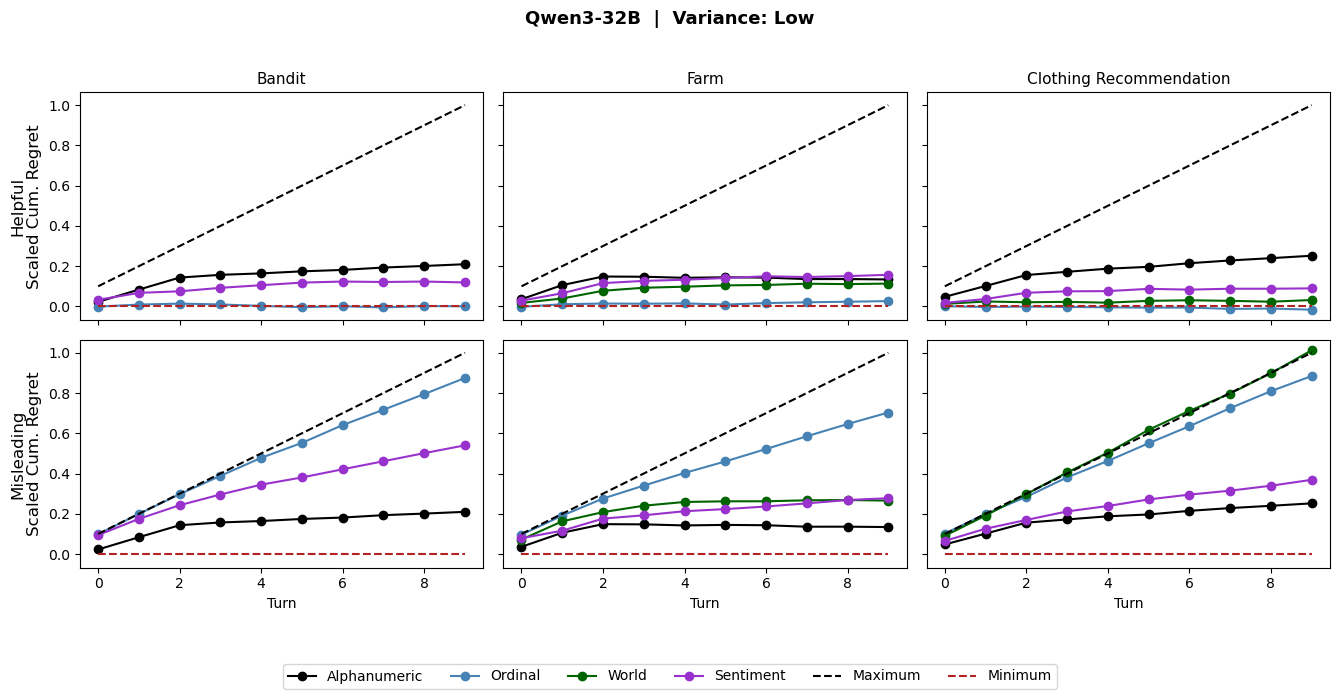

Saved cum_regret: model=Qwen3-32B, variance=Low


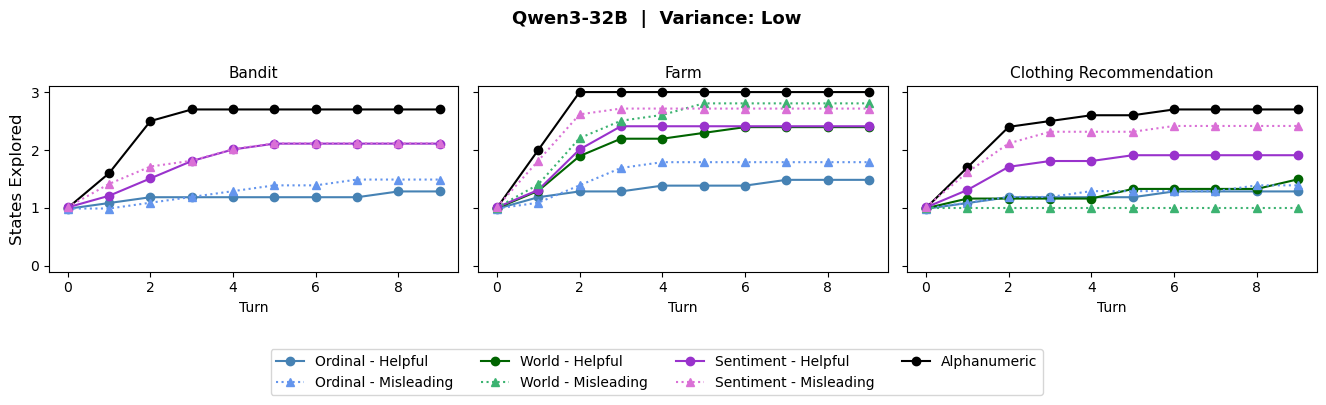

Saved exploration_count: model=Qwen3-32B, variance=Low


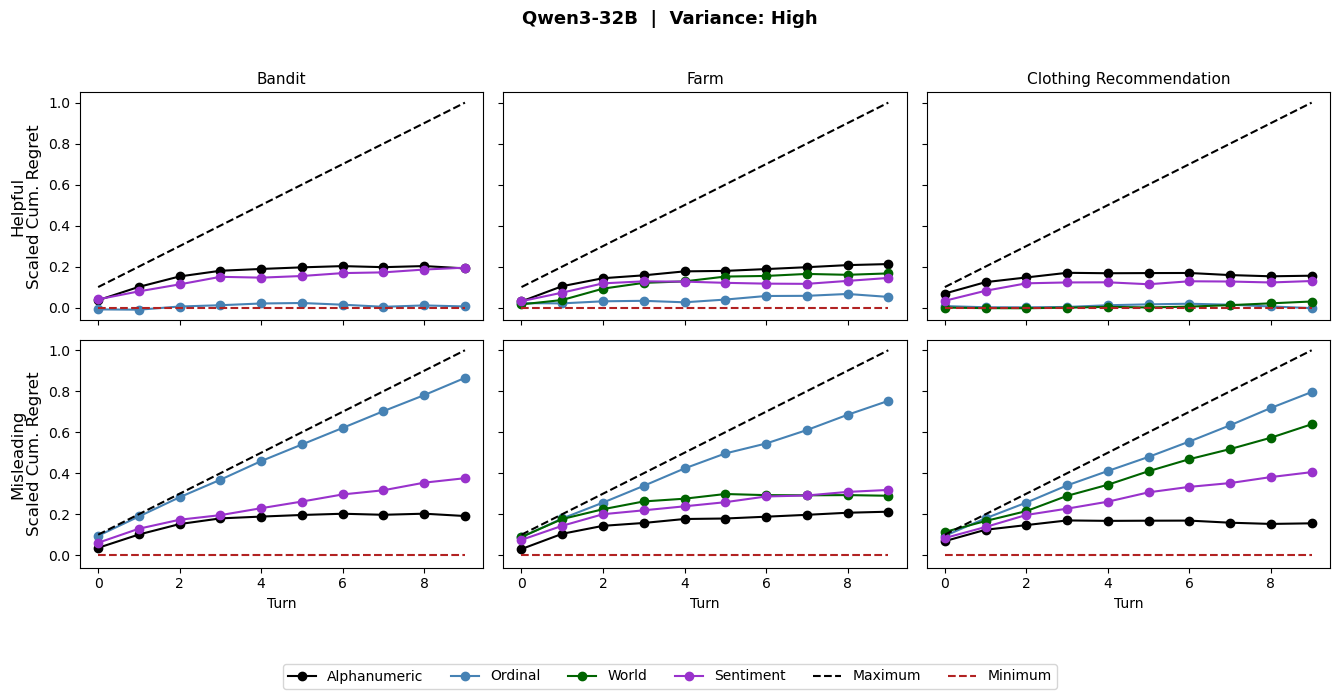

Saved cum_regret: model=Qwen3-32B, variance=High


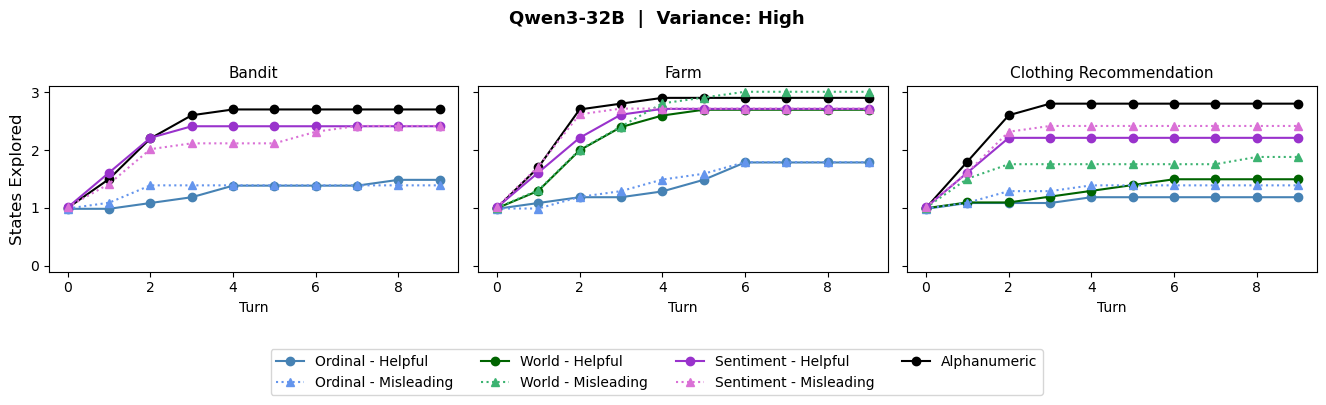

Saved exploration_count: model=Qwen3-32B, variance=High


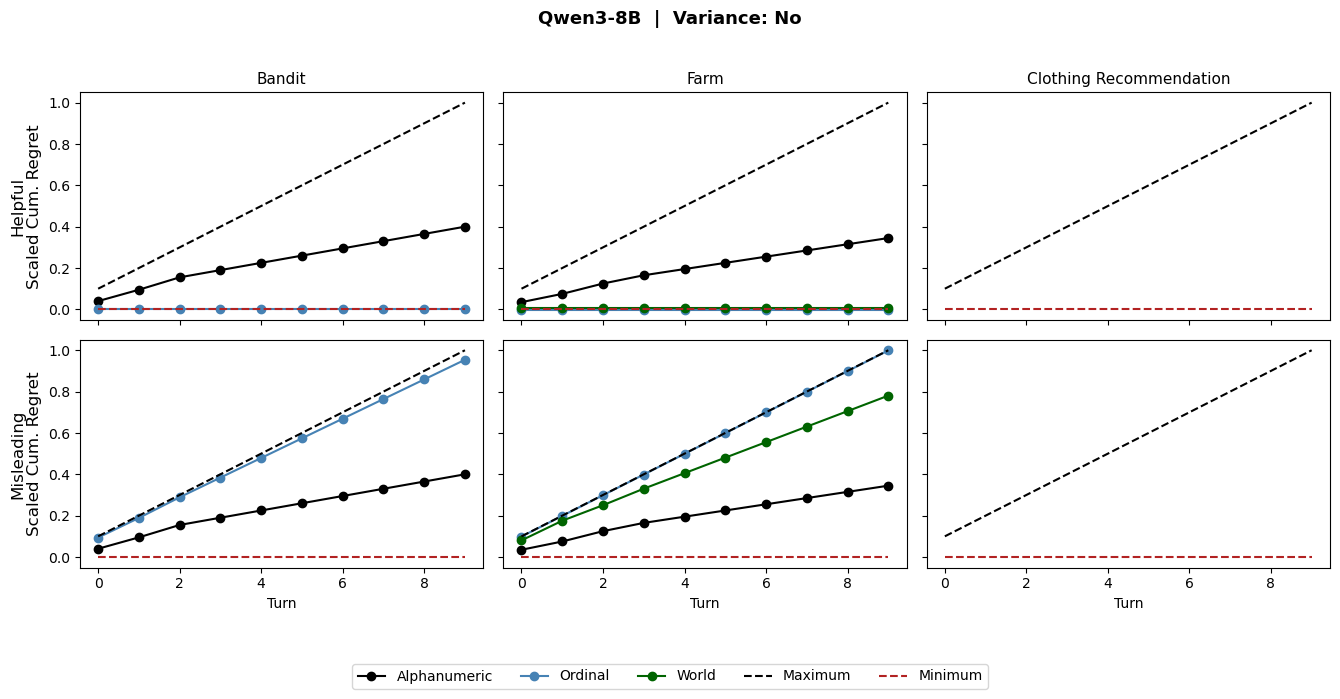

Saved cum_regret: model=Qwen3-8B, variance=No


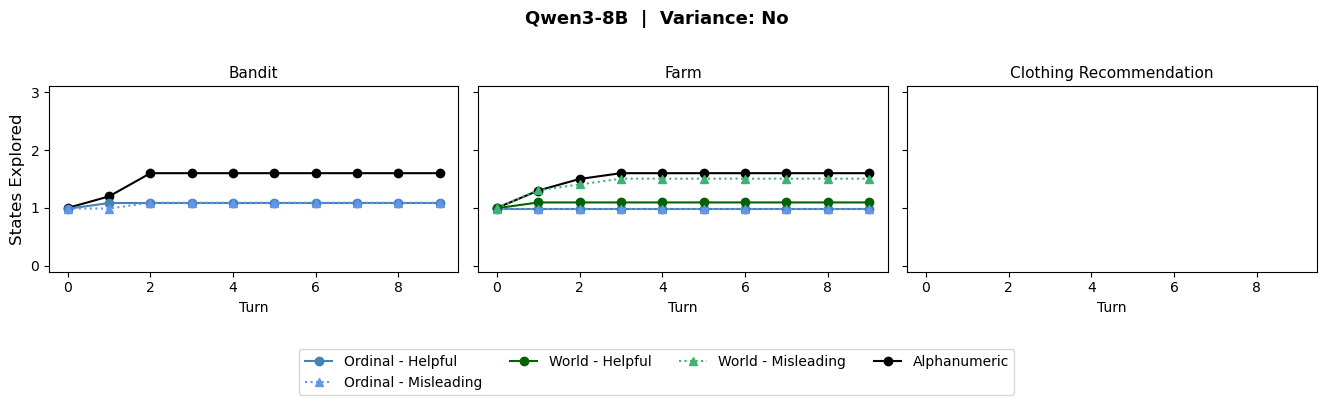

Saved exploration_count: model=Qwen3-8B, variance=No


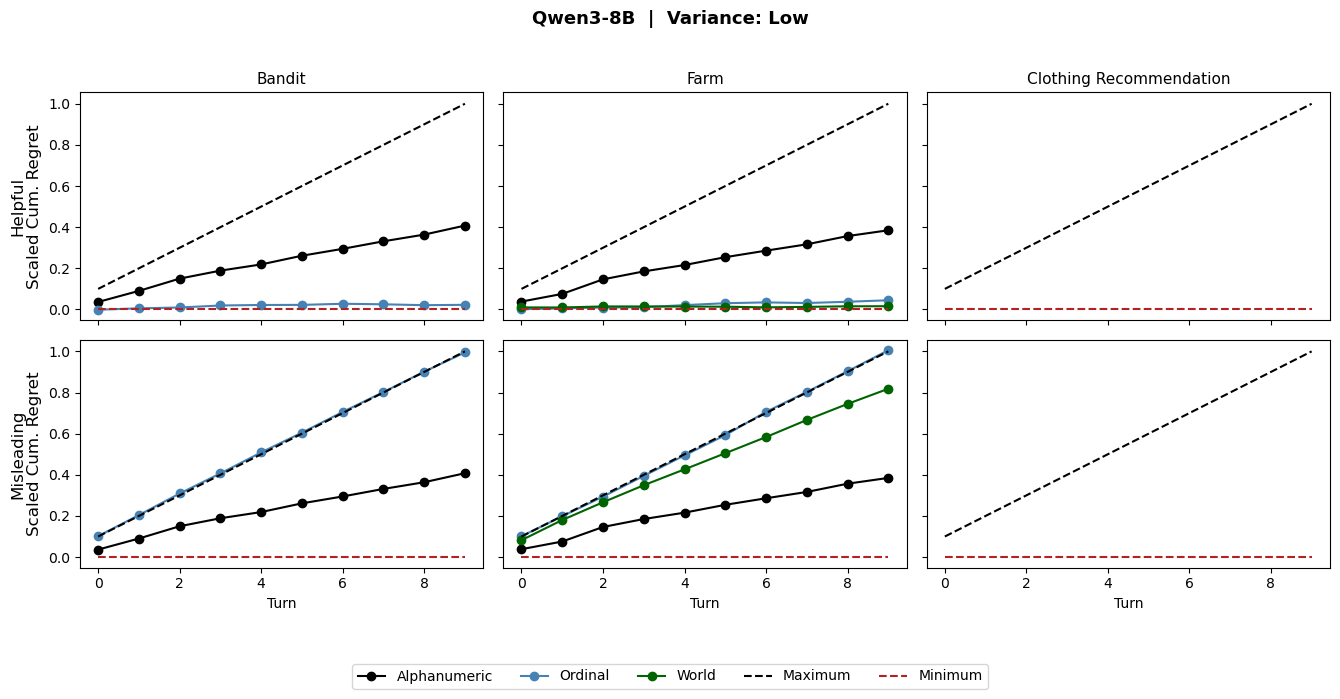

Saved cum_regret: model=Qwen3-8B, variance=Low


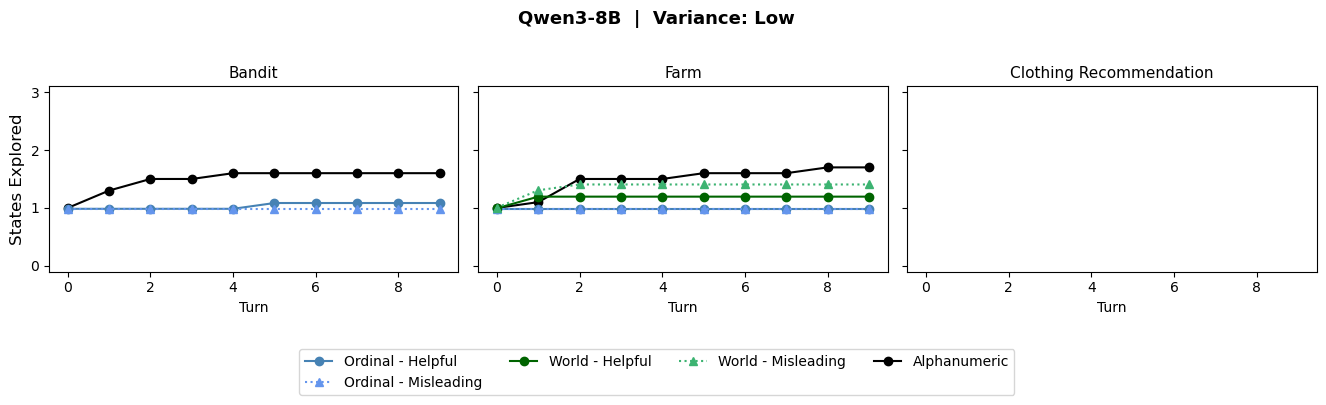

Saved exploration_count: model=Qwen3-8B, variance=Low


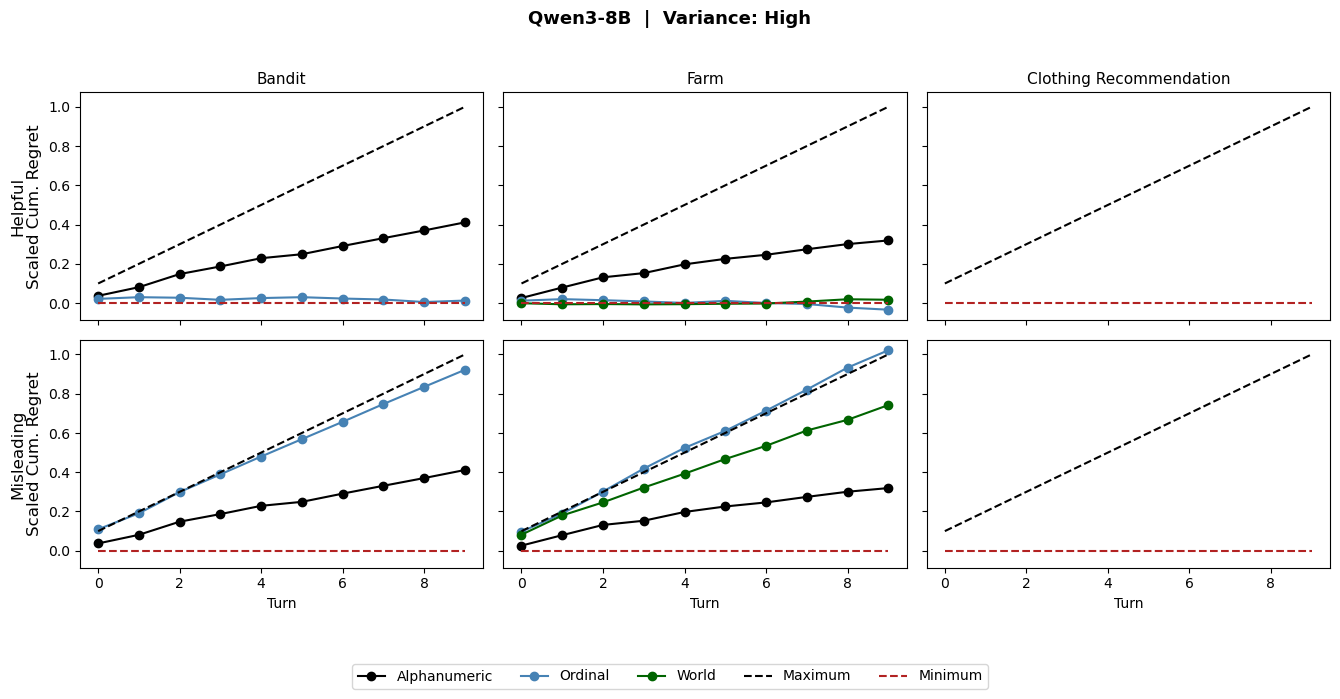

Saved cum_regret: model=Qwen3-8B, variance=High


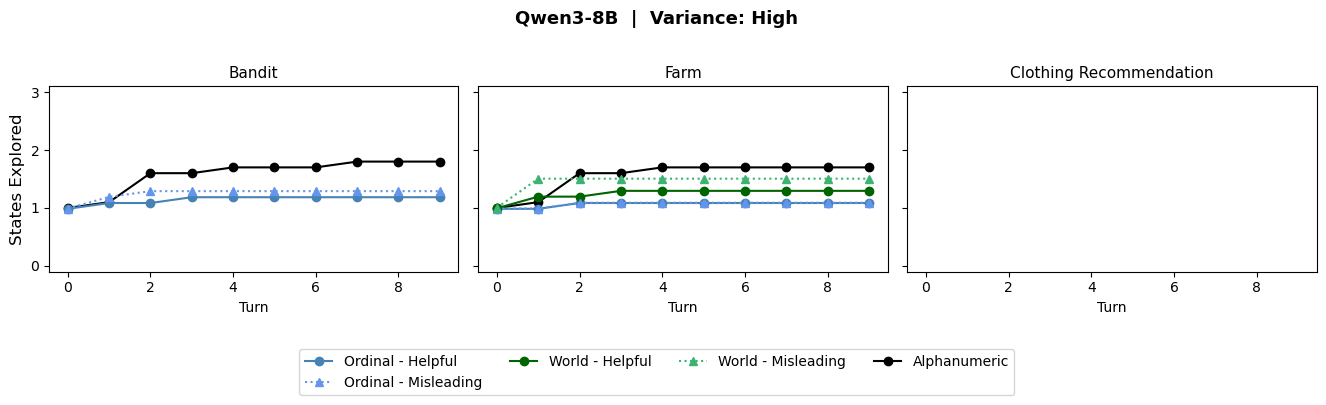

Saved exploration_count: model=Qwen3-8B, variance=High


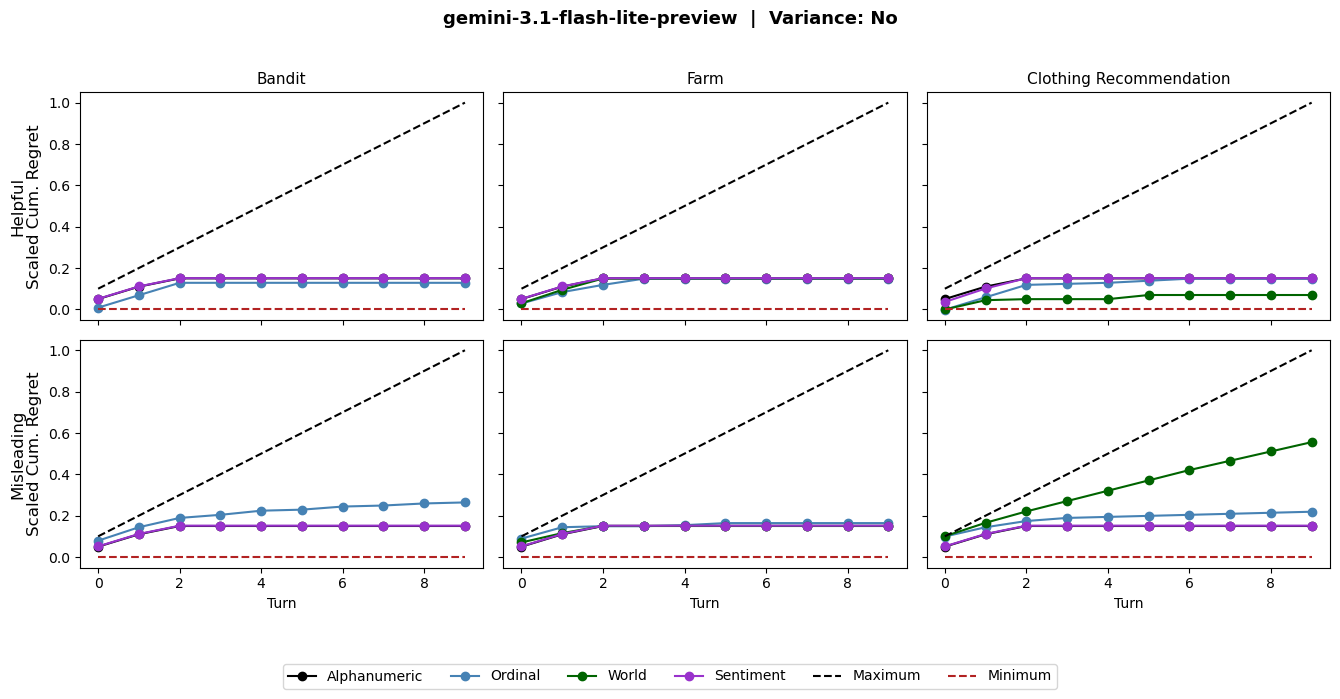

Saved cum_regret: model=gemini-3.1-flash-lite-preview, variance=No


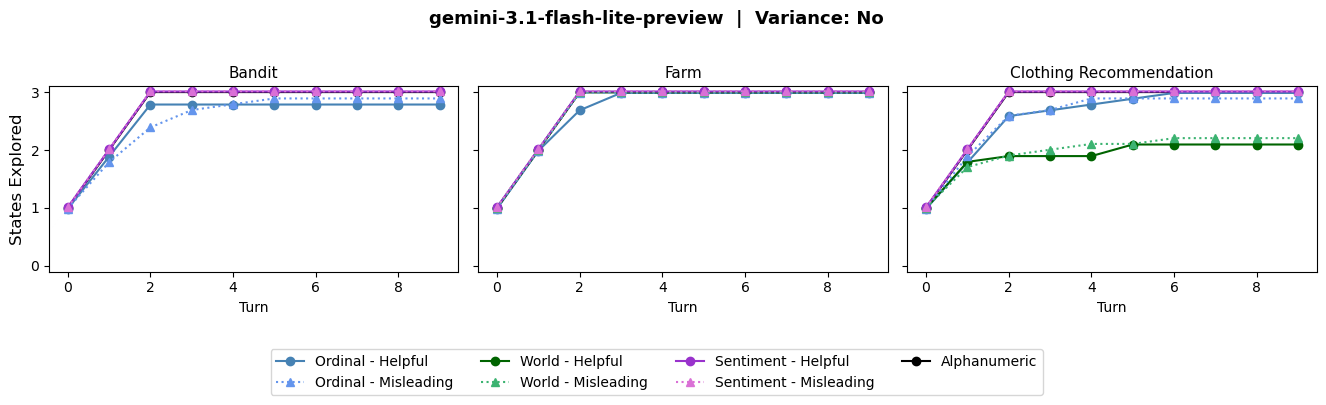

Saved exploration_count: model=gemini-3.1-flash-lite-preview, variance=No


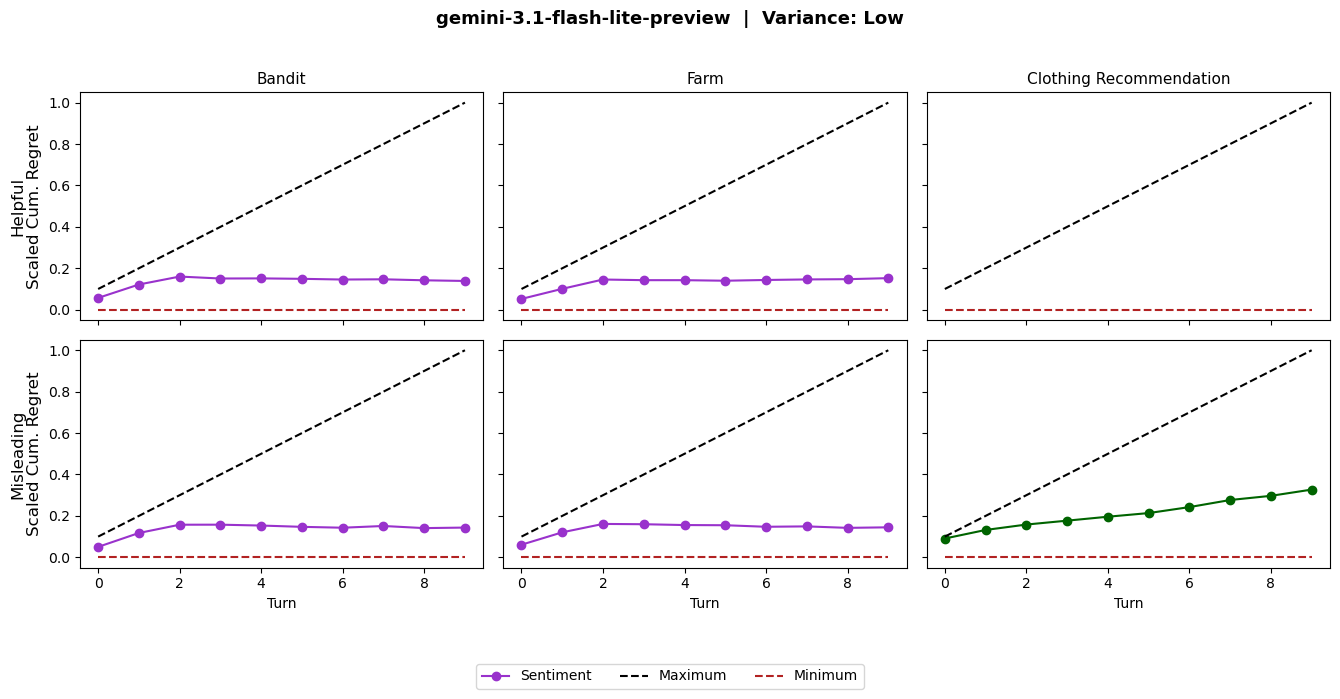

Saved cum_regret: model=gemini-3.1-flash-lite-preview, variance=Low


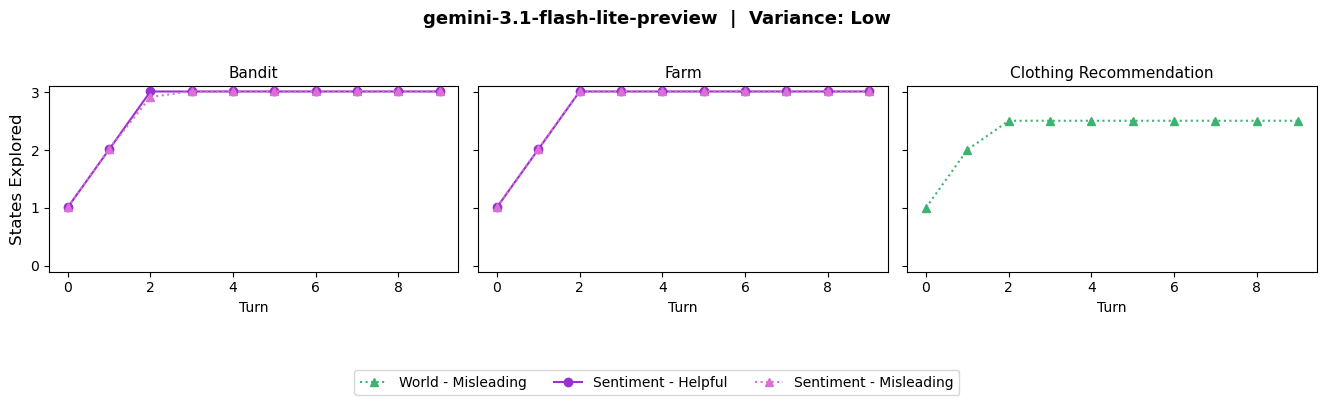

Saved exploration_count: model=gemini-3.1-flash-lite-preview, variance=Low


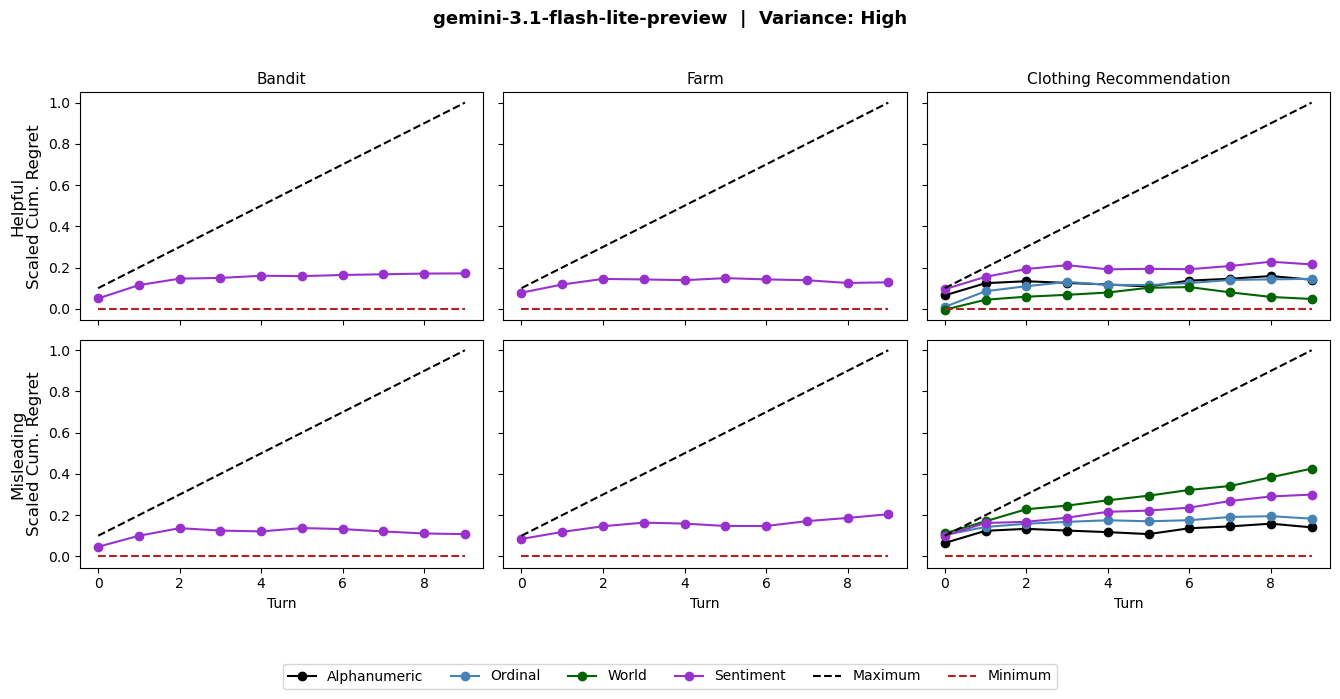

Saved cum_regret: model=gemini-3.1-flash-lite-preview, variance=High


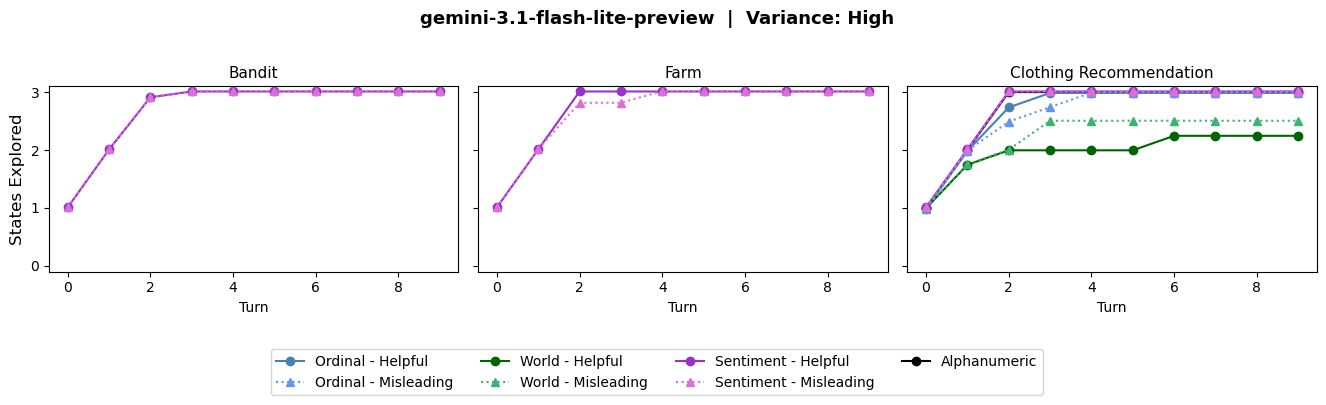

Saved exploration_count: model=gemini-3.1-flash-lite-preview, variance=High


In [6]:
all_models = sorted(results_df['model'].unique())

# Ordered domain list, restricted to those present in the data
present_domains = results_df['domain'].unique()
domains = [d for d in domain_order if d in present_domains] + \
          [d for d in present_domains if d not in domain_order]

# Extract turn numbers once from column names
turn_numbers = sorted(
    int(col.split('_')[-2])
    for col in results_df.columns
    if col.startswith('cum_regret_') and col.endswith('_mean')
)

# Jitter scale factors per metric
JITTER_SCALE = {
    'cum_regret':        0.1,   # very subtle — normalised axis is ~0–1
    'exploration_count': 1.0,
}

for model in all_models:
    model_safe = re.sub(r'[^\w\-]', '_', model)

    for variance in all_variances:
        variance_safe = variance.lower()
        subset = results_df[
            (results_df['model']    == model)   &
            (results_df['history']  == hist)    &
            (results_df['variance'] == variance) &
            (results_df['scale']    == SCALE)
        ]
        if subset.empty:
            print(f"No data for model={model}, variance={variance}, scale={SCALE} — skipping.")
            continue

        # ── Cumulative Regret: 2 rows (helpful top, mislead bottom) × N domains ──
        fig, axes = plt.subplots(
            2, len(domains),
            figsize=(4.5 * len(domains), 7),
            sharex=True, sharey=True,
        )
        if len(domains) == 1:
            axes = axes.reshape(2, 1)

        fig.suptitle(f"{model}  |  Variance: {variance}", fontsize=13, fontweight='bold')

        # Collect handles from helpful row only; keyed by nom_key for ordered legend
        cumregret_handles = {}
        bound_handles = {}
        row_labels = {0: 'Helpful', 1: 'Misleading'}

        for row_idx, group_name in enumerate(['helpful', 'mislead']):
            nomenclatures = nom_groups[group_name]
            for col_idx, domain in enumerate(domains):
                ax = axes[row_idx, col_idx]
                domain_subset = subset[subset['domain'] == domain]

                for nom_key in nomenclatures:
                    nom_df = domain_subset[
                        domain_subset['nomenclature'].str.contains(nom_key, na=False)
                    ]
                    if nom_df.empty:
                        continue

                    means = nom_df[[f"cum_regret_{t}_mean" for t in turn_numbers]].values.flatten()
                    normalizing_constant = (
                        max(rewards_per_scale[SCALE]) - min(rewards_per_scale[SCALE])
                    ) * len(means)
                    jitter = NOM_Y_JITTER[nom_key] * JITTER_SCALE['cum_regret']
                    means = [x / normalizing_constant + jitter for x in means]

                    style = NOM_STYLE_CONSTANTS[nom_key]
                    try:
                        handle, = ax.plot(turn_numbers, means, **style)
                        if row_idx == 0 and nom_key not in cumregret_handles:
                            cumregret_handles[nom_key] = handle
                    except Exception as e:
                        print(f"ERROR: model={model} domain={domain} nom={nom_key}: {e}")

                # Min / max reference bounds
                if len(turn_numbers) > 0:
                    max_step = 1.0 / len(turn_numbers)
                    bounds = {
                        'max_val': list(np.linspace(max_step, 1.0, len(turn_numbers))),
                        'min_val': [0.0] * len(turn_numbers),
                    }
                    for bound_key, bound_vals in bounds.items():
                        handle, = ax.plot(turn_numbers, bound_vals, **STYLE_CONSTANTS[bound_key])
                        if bound_key not in bound_handles:
                            bound_handles[bound_key] = handle

                if row_idx == 1:
                    ax.set_xlabel("Turn")
                if row_idx == 0:
                    ax.set_title(domain, fontsize=11)
                if col_idx == 0:
                    ax.set_ylabel(f"{row_labels[row_idx]}\n{metric_map['cum_regret']}", fontsize=12)

        # Legend: one entry per nom type (no helpful/mislead suffix), then bounds
        short_label = lambda k: NOM_STYLE_CONSTANTS[k]['label'].replace(' - Helpful', '')
        legend_order = ['alphanumeric', 'ordinal_helpful', 'world_helpful', 'sent_new_helpful']
        sorted_handles = [cumregret_handles[k] for k in legend_order if k in cumregret_handles]
        sorted_labels  = [short_label(k)       for k in legend_order if k in cumregret_handles]
        for bk in ['max_val', 'min_val']:
            if bk in bound_handles:
                sorted_handles.append(bound_handles[bk])
                sorted_labels.append(STYLE_CONSTANTS[bk]['label'])

        fig.legend(
            sorted_handles, sorted_labels,
            loc='lower center', bbox_to_anchor=(0.5, 0.0),
            ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
        )
        plt.tight_layout(rect=[0, 0.10, 1, 0.96])

        out_dir     = f"figures/cum_regret/{model_safe}"
        out_dir_png = f"figures_png/cum_regret/{model_safe}"
        os.makedirs(out_dir,     exist_ok=True)
        os.makedirs(out_dir_png, exist_ok=True)
        plt.savefig(f"{out_dir}/variance_{variance_safe}.pdf",     dpi=300, bbox_inches='tight')
        plt.savefig(f"{out_dir_png}/variance_{variance_safe}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved cum_regret: model={model}, variance={variance}")

        # ── Exploration Count: 1 row, helpful + mislead in same subplot ──
        fig, axes = plt.subplots(
            1, len(domains),
            figsize=(4.5 * len(domains), 4),
            sharex=True, sharey=True,
        )
        if len(domains) == 1:
            axes = [axes]

        fig.suptitle(f"{model}  |  Variance: {variance}", fontsize=13, fontweight='bold')

        label_to_handle = {}

        # All noms: helpful group (solid) + mislead without alphanumeric (dotted lighter)
        explor_noms = nom_groups['helpful'] + [k for k in nom_groups['mislead'] if k != 'alphanumeric']

        for col_idx, domain in enumerate(domains):
            ax = axes[col_idx]
            domain_subset = subset[subset['domain'] == domain]

            for nom_key in explor_noms:
                nom_df = domain_subset[
                    domain_subset['nomenclature'].str.contains(nom_key, na=False)
                ]
                if nom_df.empty:
                    continue

                means = nom_df[[f"exploration_count_{t}_mean" for t in turn_numbers]].values.flatten()
                jitter = NOM_Y_JITTER[nom_key] * JITTER_SCALE['exploration_count']
                means = [y + jitter for y in means]

                style = NOM_STYLE_MISLEAD_EXPLOR.get(nom_key, NOM_STYLE_CONSTANTS[nom_key])
                try:
                    handle, = ax.plot(turn_numbers, means, **style)
                    if style['label'] not in label_to_handle:
                        label_to_handle[style['label']] = handle
                except Exception as e:
                    print(f"ERROR: model={model} domain={domain} nom={nom_key}: {e}")

            ax.set_xlabel("Turn")
            ax.set_title(domain, fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(metric_map['exploration_count'], fontsize=12)
            ax.set_ylim(-0.1, 3.1)

        # Legend: interleave helpful/mislead pairs, alphanumeric last
        explor_legend_order = [
            'ordinal_helpful', 'ordinal_mislead',
            'world_helpful',   'world_mislead',
            'sent_new_helpful', 'sent_new_mislead',
            'alphanumeric',
        ]
        sorted_labels, sorted_handles = [], []
        for k in explor_legend_order:
            style = NOM_STYLE_MISLEAD_EXPLOR.get(k) or NOM_STYLE_CONSTANTS.get(k)
            if style is None:
                continue
            lbl = style['label']
            if lbl in label_to_handle:
                sorted_labels.append(lbl)
                sorted_handles.append(label_to_handle[lbl])

        fig.legend(
            sorted_handles, sorted_labels,
            loc='lower center', bbox_to_anchor=(0.5, 0.0),
            ncol=4, borderaxespad=0.5, frameon=True, fontsize=10,
        )
        plt.tight_layout(rect=[0, 0.18, 1, 0.96])

        out_dir     = f"figures/exploration_count/{model_safe}"
        out_dir_png = f"figures_png/exploration_count/{model_safe}"
        os.makedirs(out_dir,     exist_ok=True)
        os.makedirs(out_dir_png, exist_ok=True)
        plt.savefig(f"{out_dir}/variance_{variance_safe}.pdf",     dpi=300, bbox_inches='tight')
        plt.savefig(f"{out_dir_png}/variance_{variance_safe}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved exploration_count: model={model}, variance={variance}")

## Three-Model Comparison Plots

Combined figures with three rows (OLMo-3.1 32B, Qwen3-32B, Gemini), one per variance condition.

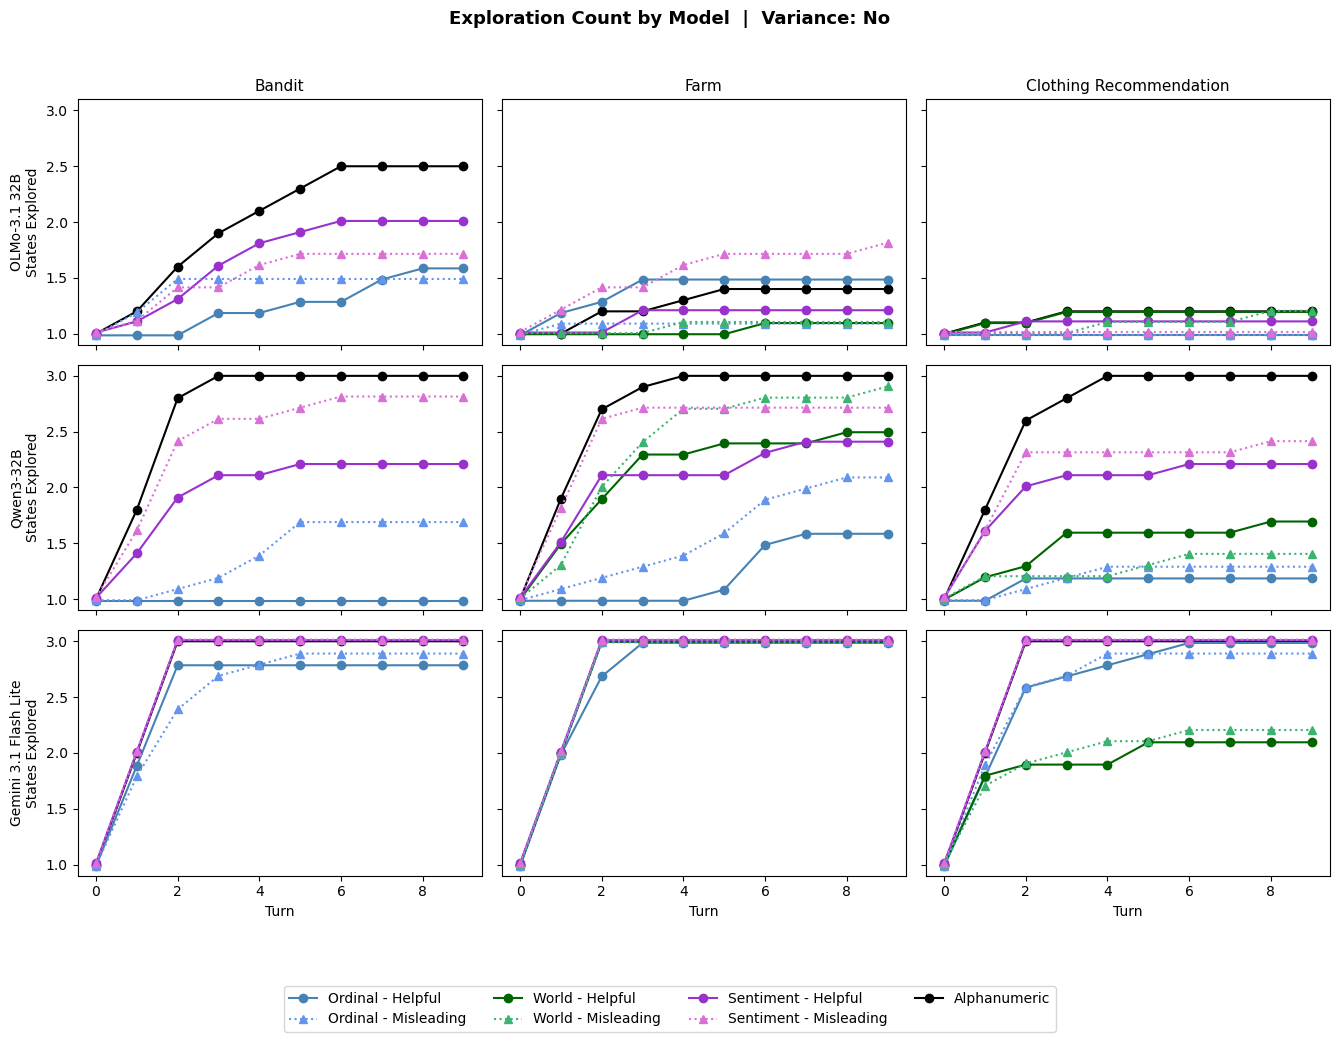

Saved three-model exploration_count: variance=No


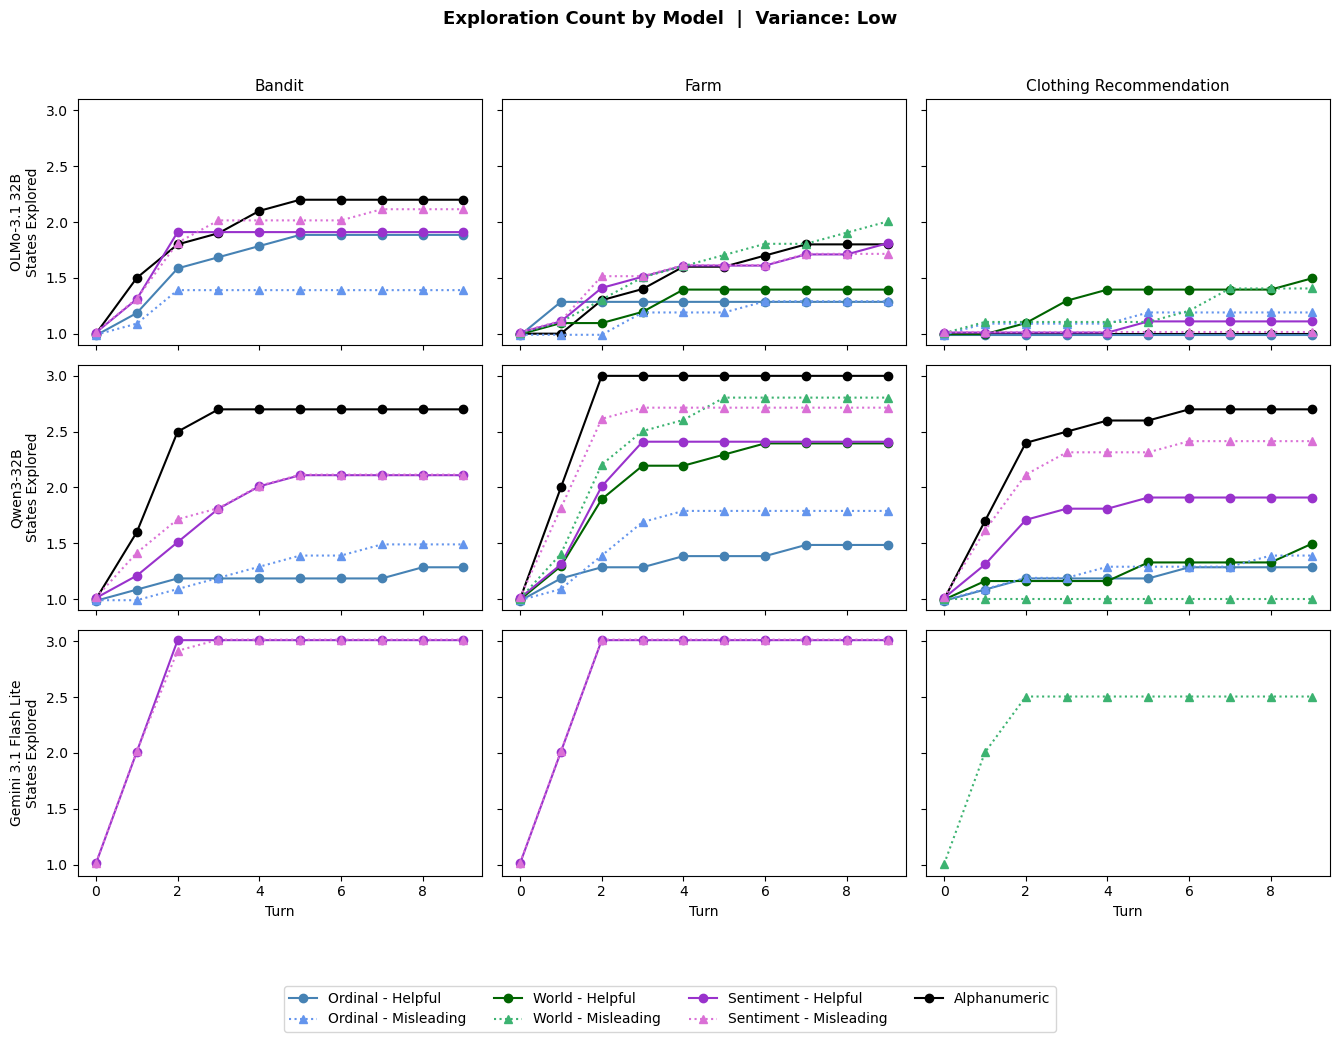

Saved three-model exploration_count: variance=Low


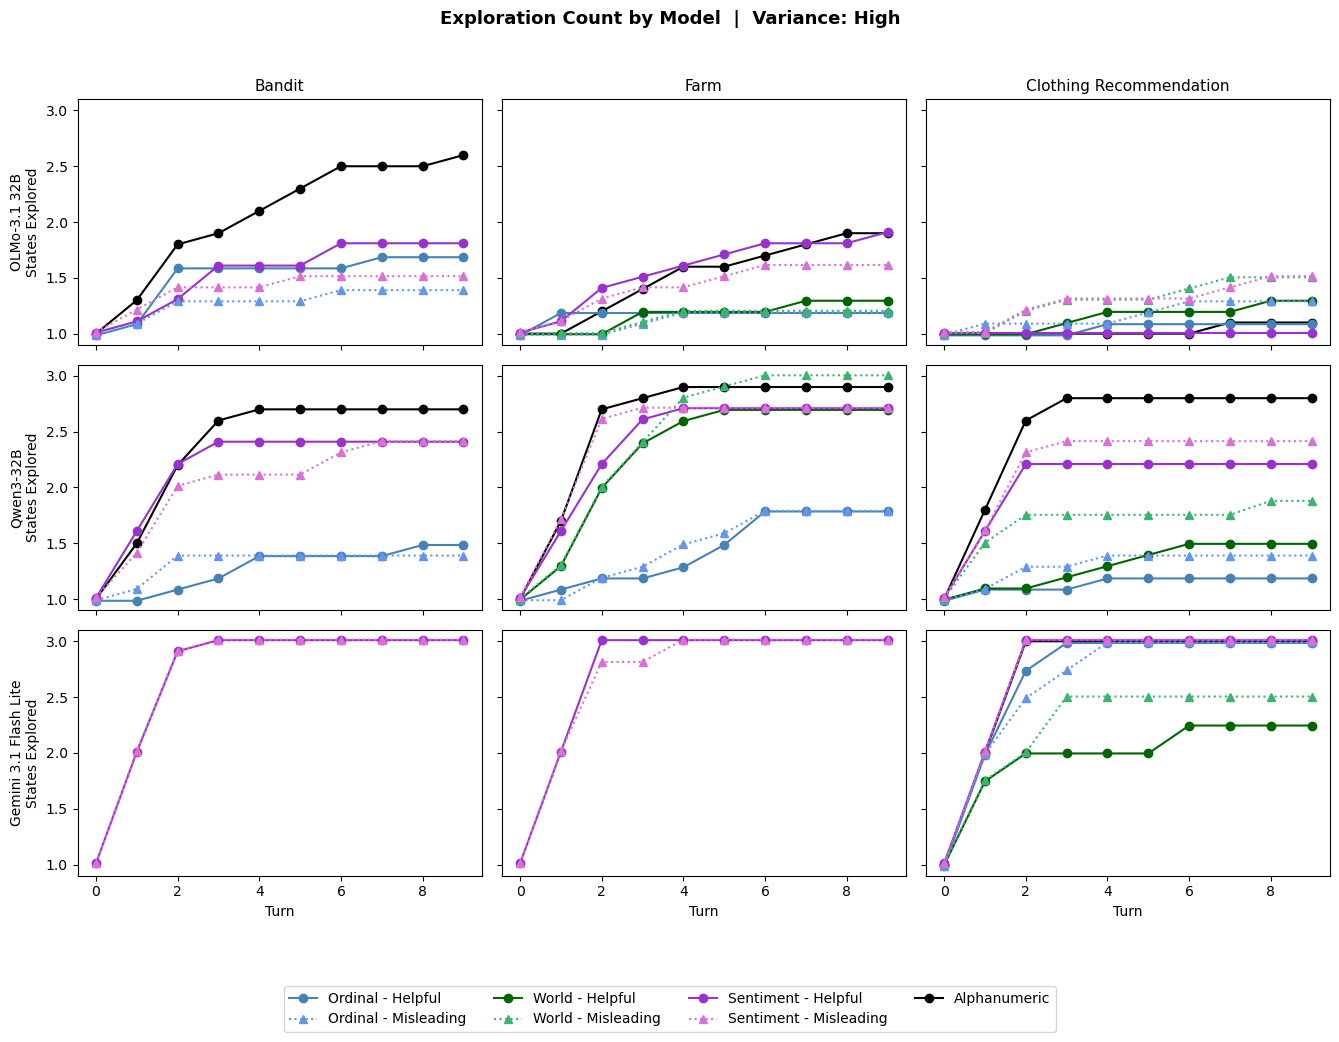

Saved three-model exploration_count: variance=High


In [8]:
THREE_MODELS = [
    ('Olmo-3.1-32B-Instruct',        'OLMo-3.1 32B'),
    ('Qwen3-32B',                     'Qwen3-32B'),
    ('gemini-3.1-flash-lite-preview', 'Gemini 3.1 Flash Lite'),
]

for variance in all_variances:
    variance_safe = variance.lower()

    # ── Exploration Count: n_models rows × N domains ──
    fig, axes = plt.subplots(
        len(THREE_MODELS), len(domains),
        figsize=(4.5 * len(domains), 3.5 * len(THREE_MODELS)),
        sharex=True, sharey=True,
    )
    if len(domains) == 1:
        axes = axes.reshape(len(THREE_MODELS), 1)

    fig.suptitle(f"Exploration Count by Model  |  Variance: {variance}", fontsize=13, fontweight='bold')

    label_to_handle = {}
    explor_noms = nom_groups['helpful'] + [k for k in nom_groups['mislead'] if k != 'alphanumeric']

    for model_idx, (model, model_label) in enumerate(THREE_MODELS):
        subset = results_df[
            (results_df['model']    == model)   &
            (results_df['history']  == hist)    &
            (results_df['variance'] == variance) &
            (results_df['scale']    == SCALE)
        ]

        for col_idx, domain in enumerate(domains):
            ax = axes[model_idx, col_idx]

            if subset.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            else:
                domain_subset = subset[subset['domain'] == domain]

                for nom_key in explor_noms:
                    nom_df = domain_subset[
                        domain_subset['nomenclature'].str.contains(nom_key, na=False)
                    ]
                    if nom_df.empty:
                        continue

                    means = nom_df[[f"exploration_count_{t}_mean" for t in turn_numbers]].values.flatten()
                    jitter = NOM_Y_JITTER[nom_key] * JITTER_SCALE['exploration_count']
                    means = [y + jitter for y in means]

                    style = NOM_STYLE_MISLEAD_EXPLOR.get(nom_key, NOM_STYLE_CONSTANTS[nom_key])
                    try:
                        handle, = ax.plot(turn_numbers, means, **style)
                        if style['label'] not in label_to_handle:
                            label_to_handle[style['label']] = handle
                    except Exception as e:
                        print(f"ERROR: model={model} domain={domain} nom={nom_key}: {e}")

            if model_idx == len(THREE_MODELS) - 1:
                ax.set_xlabel("Turn")
            if model_idx == 0:
                ax.set_title(domain, fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(f"{model_label}\n{metric_map['exploration_count']}", fontsize=10)
            ax.set_ylim(0.9, 3.1)

    explor_legend_order = [
        'ordinal_helpful', 'ordinal_mislead',
        'world_helpful',   'world_mislead',
        'sent_new_helpful', 'sent_new_mislead',
        'alphanumeric',
    ]
    sorted_labels, sorted_handles = [], []
    for k in explor_legend_order:
        style = NOM_STYLE_MISLEAD_EXPLOR.get(k) or NOM_STYLE_CONSTANTS.get(k)
        if style is None:
            continue
        lbl = style['label']
        if lbl in label_to_handle:
            sorted_labels.append(lbl)
            sorted_handles.append(label_to_handle[lbl])

    fig.legend(
        sorted_handles, sorted_labels,
        loc='lower center', bbox_to_anchor=(0.5, 0.0),
        ncol=4, borderaxespad=0.5, frameon=True, fontsize=10,
    )
    plt.tight_layout(rect=[0, 0.10, 1, 0.96])

    out_dir     = "figures/exploration_count/three_model_comparison"
    out_dir_png = "figures_png/exploration_count/three_model_comparison"
    os.makedirs(out_dir,     exist_ok=True)
    os.makedirs(out_dir_png, exist_ok=True)
    plt.savefig(f"{out_dir}/variance_{variance_safe}.pdf",     dpi=300, bbox_inches='tight')
    plt.savefig(f"{out_dir_png}/variance_{variance_safe}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved three-model exploration_count: variance={variance}")